In [1]:
# Colab setup cell: if you opened this notebook from GitHub in Colab, run this first.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/lblommesteyn/march_madness_wai_wsac_workshop.git"
REPO_DIR = Path("/content/march_madness_wai_wsac_workshop")

def run_cmd(cmd, cwd=None, check=True):
    print("$", " ".join(cmd))
    result = subprocess.run(cmd, cwd=cwd, text=True, capture_output=True)
    if result.stdout:
        print(result.stdout.strip())
    if result.stderr:
        print(result.stderr.strip())
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}: {' '.join(cmd)}")
    return result

def git_lfs_available():
    return run_cmd(["git", "lfs", "version"], check=False).returncode == 0

if "google.colab" in sys.modules:
    if not git_lfs_available():
        run_cmd(["apt-get", "-qq", "update"])
        run_cmd(["apt-get", "-qq", "install", "git-lfs"])
    if REPO_DIR.exists():
        print(f"Repo already exists at {REPO_DIR}, refreshing it.")
        run_cmd(["git", "pull"], cwd=REPO_DIR, check=False)
    else:
        run_cmd(["git", "clone", REPO_URL, str(REPO_DIR)])
    if git_lfs_available():
        run_cmd(["git", "lfs", "pull"], cwd=REPO_DIR, check=False)
    else:
        print("Warning: git-lfs is unavailable, so large files may not download.")
    os.chdir(REPO_DIR)
    print("Colab repo setup complete.")
else:
    print("Colab setup skipped because this notebook is not running in Google Colab.")

print("Working directory:", Path.cwd())


Colab setup skipped because this notebook is not running in Google Colab.
Working directory: C:\Users\16476\mm_intro_to_ml


# March Madness 2026 Workshop Notebook

This notebook is written for beginners. The point is not just to get bracket picks, but to walk through a complete machine-learning workflow in a way that works for a workshop:

1. understand the problem
2. load and inspect data
3. engineer features
4. backtest several models
5. add a stronger 2026 signal with KenPom
6. produce deterministic picks and Monte Carlo odds


## Workshop Roadmap

We will build up in layers:

- **Baseline model**: seed, record, current advanced team stats, and rating-style live features
- **Enhanced model**: margin, scoring, recent-form, and richer historical features
- **Backtesting**: compare several models across recent seasons
- **2026 forecast**: blend the live baseline with KenPom and current TeamRankings stats
- **Monte Carlo simulation**: estimate Final Four and title odds

Sources:

- Historical results mirror: `https://raw.githubusercontent.com/jfcross4/advanced_stats/master/stage2data/`
- 2026 bracket page: `https://en.wikipedia.org/wiki/2026_NCAA_Division_I_men%27s_basketball_tournament`
- Local KenPom snapshot: `kenpom_2026_snapshot.csv`
- Local TeamRankings snapshot: `teamrankings_2026_snapshot.csv`


In [2]:
# Standard library imports
from io import StringIO
import re
from pathlib import Path

# Core data stack
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Machine-learning models and metrics
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from xgboost import XGBClassifier
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

# Notebook display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

# Reproducibility matters in a workshop.
RNG = np.random.default_rng(42)

# Data locations
HIST_BASE = "https://raw.githubusercontent.com/jfcross4/advanced_stats/master/stage2data/"
BRACKET_URL = "https://en.wikipedia.org/wiki/2026_NCAA_Division_I_men%27s_basketball_tournament"
KENPOM_PATH = Path("kenpom_2026_snapshot.csv")
TEAMRANKINGS_PATH = Path("teamrankings_2026_snapshot.csv")
MASSEY_PATH = Path("MMasseyOrdinals.csv")
DETAILED_RESULTS_PATH = Path("MRegularSeasonDetailedResults.csv")


## 1. Load the historical tournament data

We need three files:

- regular-season games
- tournament games
- tournament seeds

Teaching note: the public historical mirror used here currently goes through **2022** for regular-season and tournament results, which is enough for workshop-style backtesting.


In [3]:
# Load the historical datasets used throughout the notebook.
regular_season = pd.read_csv(HIST_BASE + "MRegularSeasonCompactResults.csv")
tourney_results = pd.read_csv(HIST_BASE + "MNCAATourneyCompactResults.csv")
tourney_seeds = pd.read_csv(HIST_BASE + "MNCAATourneySeeds.csv")
massey = pd.read_csv(MASSEY_PATH, usecols=["Season", "TeamID", "RankingDayNum", "OrdinalRank"]) if MASSEY_PATH.exists() else None
regular_season_detailed = pd.read_csv(DETAILED_RESULTS_PATH) if DETAILED_RESULTS_PATH.exists() else None

# Seeds arrive as strings like W01 or Y11a, so we keep only the numeric part.
tourney_seeds["seed_num"] = tourney_seeds["Seed"].str.extract(r"(\d+)").astype(int)

print("Regular season max season:", regular_season["Season"].max())
print("Tournament max season:", tourney_results["Season"].max())
print("Seeds max season:", tourney_seeds["Season"].max())
print()
print("Regular season shape:", regular_season.shape)
print("Tournament shape:", tourney_results.shape)
print("Seeds shape:", tourney_seeds.shape)
print("Local Massey available:", massey is not None)
print("Local detailed results available:", regular_season_detailed is not None)


Regular season max season: 2022
Tournament max season: 2022
Seeds max season: 2023

Regular season shape: (176080, 8)
Tournament shape: (2384, 8)
Seeds shape: (2490, 4)
Local Massey available: True
Local detailed results available: True


## 1A. Quick historical visuals

Before modeling, it helps to see what the tournament history looks like:

- how many tournament games we have by season
- which seed lines have historically produced champions


C:\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


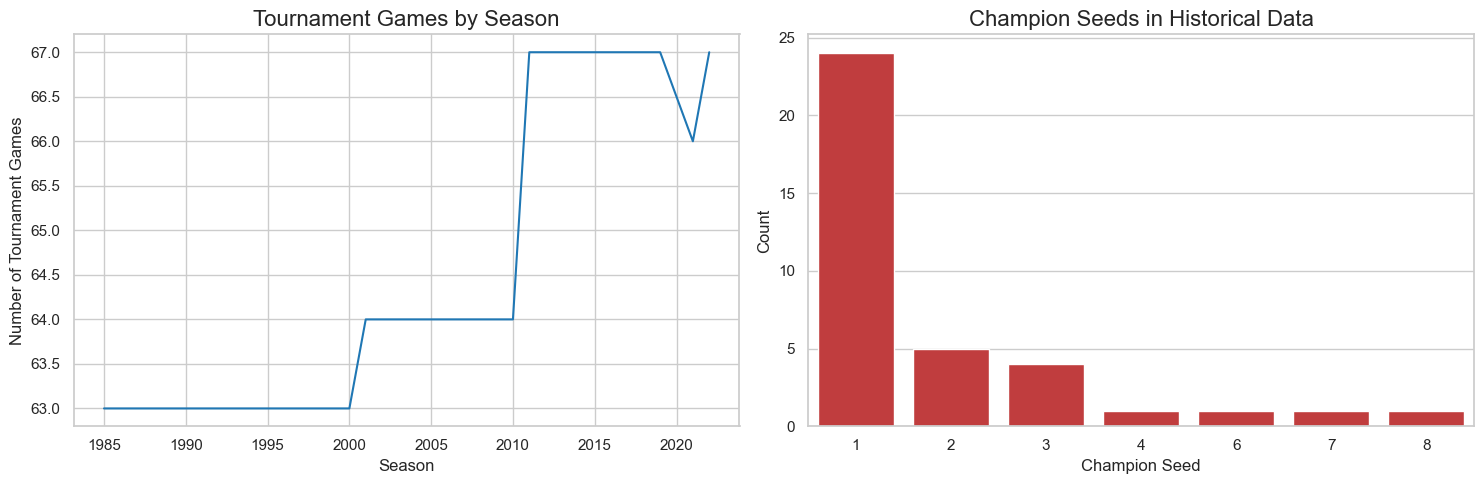

In [4]:
# Count tournament games per season so students can see the history coverage.
games_per_season = tourney_results.groupby("Season").size().reset_index(name="games")

# Find each season's champion by taking the latest tournament win in that season.
champion_games = (
    tourney_results.sort_values(["Season", "DayNum"])
    .groupby("Season")
    .tail(1)
    .merge(
        tourney_seeds[["Season", "TeamID", "seed_num"]],
        left_on=["Season", "WTeamID"],
        right_on=["Season", "TeamID"],
        how="left",
    )
    .rename(columns={"seed_num": "champion_seed"})
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=games_per_season, x="Season", y="games", ax=axes[0], color="#1f77b4")
axes[0].set_title("Tournament Games by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Number of Tournament Games")

champion_seed_counts = champion_games["champion_seed"].value_counts().sort_index()
sns.barplot(x=champion_seed_counts.index, y=champion_seed_counts.values, ax=axes[1], color="#d62728")
axes[1].set_title("Champion Seeds in Historical Data")
axes[1].set_xlabel("Champion Seed")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 1B. Upset map for common seed matchups

One useful way to motivate the problem is to look at how often classic seed-pair upsets happen historically.

This is not meant to be a perfect bracket simulator by itself. It is just a visual reminder that:

- higher seeds do win most of the time
- but some seed pairings are much less one-sided than people assume


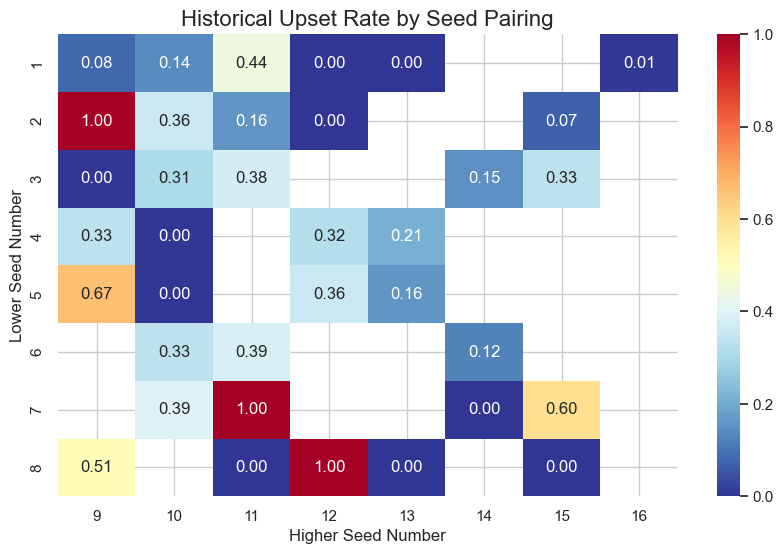

In [5]:
# Join tournament seeds onto both sides of each historical tournament game.
seed_games = (
    tourney_results
    .merge(
        tourney_seeds[["Season", "TeamID", "seed_num"]],
        left_on=["Season", "WTeamID"],
        right_on=["Season", "TeamID"],
        how="left",
    )
    .rename(columns={"seed_num": "WSeed"})
    .drop(columns="TeamID")
    .merge(
        tourney_seeds[["Season", "TeamID", "seed_num"]],
        left_on=["Season", "LTeamID"],
        right_on=["Season", "TeamID"],
        how="left",
    )
    .rename(columns={"seed_num": "LSeed"})
    .drop(columns="TeamID")
)

# Focus on classic "lower seed vs higher seed" tournament pairings.
seed_games["lower_seed"] = seed_games[["WSeed", "LSeed"]].min(axis=1)
seed_games["higher_seed"] = seed_games[["WSeed", "LSeed"]].max(axis=1)
seed_games["upset_happened"] = (seed_games["WSeed"] > seed_games["LSeed"]).astype(int)

upset_heatmap_df = (
    seed_games.loc[
        seed_games["lower_seed"].between(1, 8)
        & seed_games["higher_seed"].between(9, 16)
    ]
    .groupby(["lower_seed", "higher_seed"])["upset_happened"]
    .mean()
    .unstack()
)

plt.figure(figsize=(10, 6))
sns.heatmap(upset_heatmap_df, annot=True, fmt=".2f", cmap="RdYlBu_r")
plt.title("Historical Upset Rate by Seed Pairing")
plt.xlabel("Higher Seed Number")
plt.ylabel("Lower Seed Number")
plt.show()


## 2. Turn game results into team-season features

The raw game files are at the **game** level, but the model needs **team-season** features.

We will create:

- overall win percentage
- total wins, losses, and games played
- average scoring margin
- average points for and against
- recent 10-game win percentage
- recent 10-game scoring margin
- home / away / neutral win rates
- an end-of-regular-season rating percentile from Massey rankings when available
- advanced detailed-game stats when local detailed results are available:
  free-throw rate, 2-point rate, 3-point rate, effective field-goal percentage,
  turnover rate, offensive rebounding rate, assist rate, and a simple pace estimate


In [6]:
# Winner-side rows: every row is now one team-game from the winner's perspective.
wins = regular_season[["Season", "DayNum", "WTeamID", "WScore", "LTeamID", "LScore", "WLoc"]].copy()
wins.columns = ["Season", "DayNum", "TeamID", "TeamScore", "OppID", "OppScore", "Loc"]
wins["win"] = 1

# Loser-side rows: flip the location so everything is from the loser's perspective.
losses = regular_season[["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "WLoc"]].copy()
losses.columns = ["Season", "DayNum", "TeamID", "TeamScore", "OppID", "OppScore", "OppLoc"]
losses["Loc"] = losses["OppLoc"].map({"H": "A", "A": "H", "N": "N"})
losses = losses.drop(columns="OppLoc")
losses["win"] = 0

# Combine both perspectives so every team-game appears once.
team_games = pd.concat([wins, losses], ignore_index=True)

# Margin is a useful beginner-friendly basketball feature.
team_games["margin"] = team_games["TeamScore"] - team_games["OppScore"]


def location_win_pct(group, loc_code):
    subset = group.loc[group["Loc"] == loc_code, "win"]
    return float(subset.mean()) if len(subset) else np.nan


base_stats = (
    team_games.groupby(["Season", "TeamID"])
    .agg(
        games=("win", "size"),
        wins=("win", "sum"),
        win_pct=("win", "mean"),
        avg_margin=("margin", "mean"),
        avg_points_for=("TeamScore", "mean"),
        avg_points_against=("OppScore", "mean"),
    )
    .reset_index()
)
base_stats["losses"] = base_stats["games"] - base_stats["wins"]

recent_stats = (
    team_games.sort_values(["Season", "TeamID", "DayNum"])
    .groupby(["Season", "TeamID"])
    .tail(10)
    .groupby(["Season", "TeamID"])
    .agg(
        recent10_win_pct=("win", "mean"),
        recent10_margin=("margin", "mean"),
    )
    .reset_index()
)

location_stats = (
    team_games.groupby(["Season", "TeamID"])
    .apply(
        lambda g: pd.Series(
            {
                "home_win_pct": location_win_pct(g, "H"),
                "away_win_pct": location_win_pct(g, "A"),
                "neutral_win_pct": location_win_pct(g, "N"),
            }
        )
    )
    .reset_index()
)

team_stats = (
    base_stats
    .merge(recent_stats, on=["Season", "TeamID"], how="left")
    .merge(location_stats, on=["Season", "TeamID"], how="left")
)

# If detailed box-score results are available locally, build richer basketball features.
if regular_season_detailed is not None:
    detailed_wins = pd.DataFrame(
        {
            "Season": regular_season_detailed["Season"],
            "DayNum": regular_season_detailed["DayNum"],
            "TeamID": regular_season_detailed["WTeamID"],
            "OppID": regular_season_detailed["LTeamID"],
            "PointsFor": regular_season_detailed["WScore"],
            "PointsAgainst": regular_season_detailed["LScore"],
            "FGM": regular_season_detailed["WFGM"],
            "FGA": regular_season_detailed["WFGA"],
            "FGM3": regular_season_detailed["WFGM3"],
            "FGA3": regular_season_detailed["WFGA3"],
            "FTM": regular_season_detailed["WFTM"],
            "FTA": regular_season_detailed["WFTA"],
            "OR": regular_season_detailed["WOR"],
            "DR": regular_season_detailed["WDR"],
            "Ast": regular_season_detailed["WAst"],
            "TO": regular_season_detailed["WTO"],
            "Stl": regular_season_detailed["WStl"],
            "Blk": regular_season_detailed["WBlk"],
            "PF": regular_season_detailed["WPF"],
            "OppFGM": regular_season_detailed["LFGM"],
            "OppFGA": regular_season_detailed["LFGA"],
            "OppFGM3": regular_season_detailed["LFGM3"],
            "OppFGA3": regular_season_detailed["LFGA3"],
            "OppFTM": regular_season_detailed["LFTM"],
            "OppFTA": regular_season_detailed["LFTA"],
            "OppOR": regular_season_detailed["LOR"],
            "OppDR": regular_season_detailed["LDR"],
            "OppAst": regular_season_detailed["LAst"],
            "OppTO": regular_season_detailed["LTO"],
            "OppStl": regular_season_detailed["LStl"],
            "OppBlk": regular_season_detailed["LBlk"],
            "OppPF": regular_season_detailed["LPF"],
        }
    )

    detailed_losses = pd.DataFrame(
        {
            "Season": regular_season_detailed["Season"],
            "DayNum": regular_season_detailed["DayNum"],
            "TeamID": regular_season_detailed["LTeamID"],
            "OppID": regular_season_detailed["WTeamID"],
            "PointsFor": regular_season_detailed["LScore"],
            "PointsAgainst": regular_season_detailed["WScore"],
            "FGM": regular_season_detailed["LFGM"],
            "FGA": regular_season_detailed["LFGA"],
            "FGM3": regular_season_detailed["LFGM3"],
            "FGA3": regular_season_detailed["LFGA3"],
            "FTM": regular_season_detailed["LFTM"],
            "FTA": regular_season_detailed["LFTA"],
            "OR": regular_season_detailed["LOR"],
            "DR": regular_season_detailed["LDR"],
            "Ast": regular_season_detailed["LAst"],
            "TO": regular_season_detailed["LTO"],
            "Stl": regular_season_detailed["LStl"],
            "Blk": regular_season_detailed["LBlk"],
            "PF": regular_season_detailed["LPF"],
            "OppFGM": regular_season_detailed["WFGM"],
            "OppFGA": regular_season_detailed["WFGA"],
            "OppFGM3": regular_season_detailed["WFGM3"],
            "OppFGA3": regular_season_detailed["WFGA3"],
            "OppFTM": regular_season_detailed["WFTM"],
            "OppFTA": regular_season_detailed["WFTA"],
            "OppOR": regular_season_detailed["WOR"],
            "OppDR": regular_season_detailed["WDR"],
            "OppAst": regular_season_detailed["WAst"],
            "OppTO": regular_season_detailed["WTO"],
            "OppStl": regular_season_detailed["WStl"],
            "OppBlk": regular_season_detailed["WBlk"],
            "OppPF": regular_season_detailed["WPF"],
        }
    )

    detailed_team_games = pd.concat([detailed_wins, detailed_losses], ignore_index=True)

    # Shot mix and efficiency.
    detailed_team_games["two_pa"] = detailed_team_games["FGA"] - detailed_team_games["FGA3"]
    detailed_team_games["two_pm"] = detailed_team_games["FGM"] - detailed_team_games["FGM3"]
    detailed_team_games["two_pt_pct"] = detailed_team_games["two_pm"] / detailed_team_games["two_pa"].replace(0, np.nan)
    detailed_team_games["three_pt_pct"] = detailed_team_games["FGM3"] / detailed_team_games["FGA3"].replace(0, np.nan)
    detailed_team_games["efg_pct"] = (detailed_team_games["FGM"] + 0.5 * detailed_team_games["FGM3"]) / detailed_team_games["FGA"].replace(0, np.nan)
    detailed_team_games["ft_rate"] = detailed_team_games["FTA"] / detailed_team_games["FGA"].replace(0, np.nan)
    detailed_team_games["three_rate"] = detailed_team_games["FGA3"] / detailed_team_games["FGA"].replace(0, np.nan)
    detailed_team_games["two_rate"] = detailed_team_games["two_pa"] / detailed_team_games["FGA"].replace(0, np.nan)

    # Possession-style features.
    detailed_team_games["team_possessions"] = (
        detailed_team_games["FGA"]
        - detailed_team_games["OR"]
        + detailed_team_games["TO"]
        + 0.44 * detailed_team_games["FTA"]
    )
    detailed_team_games["opp_possessions"] = (
        detailed_team_games["OppFGA"]
        - detailed_team_games["OppOR"]
        + detailed_team_games["OppTO"]
        + 0.44 * detailed_team_games["OppFTA"]
    )
    detailed_team_games["pace"] = (detailed_team_games["team_possessions"] + detailed_team_games["opp_possessions"]) / 2
    detailed_team_games["off_rating"] = 100 * detailed_team_games["PointsFor"] / detailed_team_games["team_possessions"].replace(0, np.nan)
    detailed_team_games["def_rating"] = 100 * detailed_team_games["PointsAgainst"] / detailed_team_games["opp_possessions"].replace(0, np.nan)
    detailed_team_games["net_rating"] = detailed_team_games["off_rating"] - detailed_team_games["def_rating"]
    detailed_team_games["turnover_rate"] = detailed_team_games["TO"] / detailed_team_games["team_possessions"].replace(0, np.nan)
    detailed_team_games["ast_rate"] = detailed_team_games["Ast"] / detailed_team_games["FGM"].replace(0, np.nan)
    detailed_team_games["orb_rate"] = detailed_team_games["OR"] / (detailed_team_games["OR"] + detailed_team_games["OppDR"]).replace(0, np.nan)
    detailed_team_games["shot_selection_balance"] = detailed_team_games["three_rate"] - detailed_team_games["ft_rate"]

    detailed_features = (
        detailed_team_games.groupby(["Season", "TeamID"])
        .agg(
            avg_ft_rate=("ft_rate", "mean"),
            avg_three_rate=("three_rate", "mean"),
            avg_two_rate=("two_rate", "mean"),
            avg_two_pt_pct=("two_pt_pct", "mean"),
            avg_three_pt_pct=("three_pt_pct", "mean"),
            avg_efg_pct=("efg_pct", "mean"),
            avg_pace=("pace", "mean"),
            avg_off_rating=("off_rating", "mean"),
            avg_def_rating=("def_rating", "mean"),
            avg_net_rating=("net_rating", "mean"),
            avg_turnover_rate=("turnover_rate", "mean"),
            avg_ast_rate=("ast_rate", "mean"),
            avg_orb_rate=("orb_rate", "mean"),
            avg_shot_selection_balance=("shot_selection_balance", "mean"),
        )
        .reset_index()
    )

    team_stats = team_stats.merge(detailed_features, on=["Season", "TeamID"], how="left")

# If local Massey rankings are available, convert end-of-regular-season ranks into a 0-1 strength percentile.
if massey is not None:
    massey_work = massey.loc[massey["RankingDayNum"] <= 133].copy()
    last_rank_day = massey_work.groupby("Season")["RankingDayNum"].transform("max")
    massey_work = massey_work.loc[last_rank_day == massey_work["RankingDayNum"]].copy()
    massey_summary = (
        massey_work.groupby(["Season", "TeamID"])["OrdinalRank"]
        .mean()
        .reset_index(name="mean_rank")
    )
    season_rank_max = massey_summary.groupby("Season")["mean_rank"].transform("max")
    massey_summary["rank_pct"] = 1 - ((massey_summary["mean_rank"] - 1) / (season_rank_max - 1).replace(0, np.nan))
    massey_summary["rank_pct"] = massey_summary["rank_pct"].fillna(0.5)
    team_stats = team_stats.merge(massey_summary[["Season", "TeamID", "mean_rank", "rank_pct"]], on=["Season", "TeamID"], how="left")
else:
    team_stats["mean_rank"] = np.nan
    team_stats["rank_pct"] = 0.5

# If a team has no games in one location bucket, fall back to overall win rate.
for col in ["home_win_pct", "away_win_pct", "neutral_win_pct"]:
    team_stats[col] = team_stats[col].fillna(team_stats["win_pct"])
team_stats["rank_pct"] = team_stats["rank_pct"].fillna(0.5)
team_stats["mean_rank"] = team_stats["mean_rank"].fillna(team_stats.groupby("Season")["mean_rank"].transform("median"))
team_stats["mean_rank"] = team_stats["mean_rank"].fillna(team_stats["mean_rank"].median())

display(team_stats.head())


C:\Users\16476\AppData\Local\Temp\ipykernel_67804\2682879028.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Season,TeamID,games,wins,win_pct,avg_margin,avg_points_for,avg_points_against,losses,recent10_win_pct,recent10_margin,home_win_pct,away_win_pct,neutral_win_pct,avg_ft_rate,avg_three_rate,avg_two_rate,avg_two_pt_pct,avg_three_pt_pct,avg_efg_pct,avg_pace,avg_off_rating,avg_def_rating,avg_net_rating,avg_turnover_rate,avg_ast_rate,avg_orb_rate,avg_shot_selection_balance,mean_rank,rank_pct
0,1985,1102,24,5,0.208333,-5.791667,63.083333,68.875000,19,0.3,-2.6,0.200000,0.250000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.227564,0.5
1,1985,1103,23,9,0.391304,-3.043478,61.043478,64.086957,14,0.4,-4.3,0.538462,0.200000,0.391304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.227564,0.5
2,1985,1104,30,21,0.700000,7.800000,68.500000,60.700000,9,0.7,9.6,0.937500,0.454545,0.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.227564,0.5
3,1985,1106,24,10,0.416667,-3.791667,71.625000,75.416667,14,0.6,-2.3,0.888889,0.090909,0.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.227564,0.5
4,1985,1108,25,19,0.760000,7.960000,83.000000,75.040000,6,0.9,7.4,0.888889,0.666667,0.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.227564,0.5


## 3. Convert tournament games into model-ready rows

Each historical tournament game becomes two rows:

- Team A vs Team B, label = 1
- Team B vs Team A, label = 0


In [7]:
# Start from tournament outcomes, then merge in seeds and team-season features
# for both the winner and loser side of each game.
games = (
    tourney_results
    .merge(tourney_seeds[["Season", "TeamID", "seed_num"]], left_on=["Season", "WTeamID"], right_on=["Season", "TeamID"])
    .rename(columns={"seed_num": "WSeed"})
    .drop(columns="TeamID")
    .merge(tourney_seeds[["Season", "TeamID", "seed_num"]], left_on=["Season", "LTeamID"], right_on=["Season", "TeamID"])
    .rename(columns={"seed_num": "LSeed"})
    .drop(columns="TeamID")
    .merge(team_stats, left_on=["Season", "WTeamID"], right_on=["Season", "TeamID"])
    .rename(columns={c: f"W_{c}" for c in team_stats.columns if c not in ["Season", "TeamID"]})
    .drop(columns="TeamID")
    .merge(team_stats, left_on=["Season", "LTeamID"], right_on=["Season", "TeamID"])
    .rename(columns={c: f"L_{c}" for c in team_stats.columns if c not in ["Season", "TeamID"]})
    .drop(columns="TeamID")
)

stat_cols = [
    "games", "wins", "losses", "win_pct", "avg_margin", "avg_points_for", "avg_points_against",
    "recent10_win_pct", "recent10_margin", "home_win_pct", "away_win_pct", "neutral_win_pct",
    "rank_pct", "mean_rank",
    "avg_ft_rate", "avg_three_rate", "avg_two_rate", "avg_two_pt_pct", "avg_three_pt_pct",
    "avg_efg_pct", "avg_pace", "avg_off_rating", "avg_def_rating", "avg_net_rating",
    "avg_turnover_rate", "avg_ast_rate", "avg_orb_rate", "avg_shot_selection_balance",
]

# These are the richer stats we can now recreate for the live 2026 field from TeamRankings.
live_advanced_feature_map = {
    "avg_ft_rate": "ft_rate",
    "avg_three_rate": "three_rate",
    "avg_two_rate": "two_rate",
    "avg_two_pt_pct": "two_pt_pct",
    "avg_three_pt_pct": "three_pt_pct",
    "avg_efg_pct": "efg_pct",
    "avg_pace": "pace",
    "avg_off_rating": "off_rating",
    "avg_def_rating": "def_rating",
    "avg_net_rating": "net_rating",
    "avg_turnover_rate": "turnover_rate",
    "avg_ast_rate": "ast_rate",
    "avg_orb_rate": "orb_rate",
    "avg_shot_selection_balance": "shot_selection_balance",
}

# We will build two datasets:
# 1. portable_df: only features we can recreate for the live 2026 field
# 2. enhanced_df: richer features for stronger historical learning
portable_rows = []
enhanced_rows = []

for _, row in games.iterrows():
    # Winner-view row
    common_w = {
        "Season": row["Season"], "label": 1, "team_seed": row["WSeed"], "opp_seed": row["LSeed"],
        "seed_diff": row["LSeed"] - row["WSeed"],
        "team_games": row["W_games"], "opp_games": row["L_games"], "games_diff": row["W_games"] - row["L_games"],
        "team_wins": row["W_wins"], "opp_wins": row["L_wins"], "wins_diff": row["W_wins"] - row["L_wins"],
        "team_losses": row["W_losses"], "opp_losses": row["L_losses"], "losses_diff": row["L_losses"] - row["W_losses"],
        "team_win_pct": row["W_win_pct"], "opp_win_pct": row["L_win_pct"], "win_pct_diff": row["W_win_pct"] - row["L_win_pct"],
        "team_rank_pct": row["W_rank_pct"], "opp_rank_pct": row["L_rank_pct"], "rank_pct_diff": row["W_rank_pct"] - row["L_rank_pct"],
        "team_mean_rank": row["W_mean_rank"], "opp_mean_rank": row["L_mean_rank"], "mean_rank_gap": row["L_mean_rank"] - row["W_mean_rank"],
    }
    # Loser-view row
    common_l = {
        "Season": row["Season"], "label": 0, "team_seed": row["LSeed"], "opp_seed": row["WSeed"],
        "seed_diff": row["WSeed"] - row["LSeed"],
        "team_games": row["L_games"], "opp_games": row["W_games"], "games_diff": row["L_games"] - row["W_games"],
        "team_wins": row["L_wins"], "opp_wins": row["W_wins"], "wins_diff": row["L_wins"] - row["W_wins"],
        "team_losses": row["L_losses"], "opp_losses": row["W_losses"], "losses_diff": row["W_losses"] - row["L_losses"],
        "team_win_pct": row["L_win_pct"], "opp_win_pct": row["W_win_pct"], "win_pct_diff": row["L_win_pct"] - row["W_win_pct"],
        "team_rank_pct": row["L_rank_pct"], "opp_rank_pct": row["W_rank_pct"], "rank_pct_diff": row["L_rank_pct"] - row["W_rank_pct"],
        "team_mean_rank": row["L_mean_rank"], "opp_mean_rank": row["W_mean_rank"], "mean_rank_gap": row["W_mean_rank"] - row["L_mean_rank"],
    }
    for hist_col, live_col in live_advanced_feature_map.items():
        common_w[f"team_{live_col}"] = row[f"W_{hist_col}"]
        common_w[f"opp_{live_col}"] = row[f"L_{hist_col}"]
        common_w[f"{live_col}_diff"] = row[f"W_{hist_col}"] - row[f"L_{hist_col}"]
        common_l[f"team_{live_col}"] = row[f"L_{hist_col}"]
        common_l[f"opp_{live_col}"] = row[f"W_{hist_col}"]
        common_l[f"{live_col}_diff"] = row[f"L_{hist_col}"] - row[f"W_{hist_col}"]
    portable_rows.extend([common_w.copy(), common_l.copy()])

    # The enhanced version keeps both raw team stats and stat differences.
    enhanced_w = common_w.copy()
    enhanced_l = common_l.copy()
    for col in stat_cols:
        enhanced_w[f"team_{col}"] = row[f"W_{col}"]
        enhanced_w[f"opp_{col}"] = row[f"L_{col}"]
        enhanced_w[f"{col}_diff"] = row[f"W_{col}"] - row[f"L_{col}"]
        enhanced_l[f"team_{col}"] = row[f"L_{col}"]
        enhanced_l[f"opp_{col}"] = row[f"W_{col}"]
        enhanced_l[f"{col}_diff"] = row[f"L_{col}"] - row[f"W_{col}"]
    enhanced_rows.extend([enhanced_w, enhanced_l])

portable_df = pd.DataFrame(portable_rows).reset_index(drop=True)
enhanced_df = pd.DataFrame(enhanced_rows).reset_index(drop=True)

# The enhanced feature set relies on detailed box-score data, which starts later than the compact mirror.
if regular_season_detailed is not None:
    enhanced_start_season = int(regular_season_detailed["Season"].min())
    portable_df = portable_df.loc[portable_df["Season"] >= enhanced_start_season].copy()
    enhanced_df = enhanced_df.loc[enhanced_df["Season"] >= enhanced_start_season].copy()
portable_df = portable_df.dropna().reset_index(drop=True)
enhanced_df = enhanced_df.fillna(0).reset_index(drop=True)

# Exclude the target column and season label when building the feature lists.
PORTABLE_FEATURES = [c for c in portable_df.columns if c not in ["Season", "label"]]
ENHANCED_FEATURES = [c for c in enhanced_df.columns if c not in ["Season", "label"]]
print("Portable feature count:", len(PORTABLE_FEATURES))
print("Enhanced feature count:", len(ENHANCED_FEATURES))
if regular_season_detailed is not None:
    print("Portable live-feature era starts:", enhanced_start_season)
    print("Enhanced detailed-feature era starts:", enhanced_start_season)
display(enhanced_df.head())


Portable feature count: 63
Enhanced feature count: 130
Portable live-feature era starts: 2003
Enhanced detailed-feature era starts: 2003


,Season,label,team_seed,opp_seed,seed_diff,team_games,opp_games,games_diff,team_wins,opp_wins,wins_diff,team_losses,opp_losses,losses_diff,team_win_pct,opp_win_pct,win_pct_diff,team_rank_pct,opp_rank_pct,rank_pct_diff,team_mean_rank,opp_mean_rank,mean_rank_gap,team_ft_rate,opp_ft_rate,ft_rate_diff,team_three_rate,opp_three_rate,three_rate_diff,team_two_rate,opp_two_rate,two_rate_diff,team_two_pt_pct,opp_two_pt_pct,two_pt_pct_diff,team_three_pt_pct,opp_three_pt_pct,three_pt_pct_diff,team_efg_pct,opp_efg_pct,efg_pct_diff,team_pace,opp_pace,pace_diff,team_off_rating,opp_off_rating,off_rating_diff,team_def_rating,opp_def_rating,def_rating_diff,...,home_win_pct_diff,team_away_win_pct,opp_away_win_pct,away_win_pct_diff,team_neutral_win_pct,opp_neutral_win_pct,neutral_win_pct_diff,mean_rank_diff,team_avg_ft_rate,opp_avg_ft_rate,avg_ft_rate_diff,team_avg_three_rate,opp_avg_three_rate,avg_three_rate_diff,team_avg_two_rate,opp_avg_two_rate,avg_two_rate_diff,team_avg_two_pt_pct,opp_avg_two_pt_pct,avg_two_pt_pct_diff,team_avg_three_pt_pct,opp_avg_three_pt_pct,avg_three_pt_pct_diff,team_avg_efg_pct,opp_avg_efg_pct,avg_efg_pct_diff,team_avg_pace,opp_avg_pace,avg_pace_diff,team_avg_off_rating,opp_avg_off_rating,avg_off_rating_diff,team_avg_def_rating,opp_avg_def_rating,avg_def_rating_diff,team_avg_net_rating,opp_avg_net_rating,avg_net_rating_diff,team_avg_turnover_rate,opp_avg_turnover_rate,avg_turnover_rate_diff,team_avg_ast_rate,opp_avg_ast_rate,avg_ast_rate_diff,team_avg_orb_rate,opp_avg_orb_rate,avg_orb_rate_diff,team_avg_shot_selection_balance,opp_avg_shot_selection_balance,avg_shot_selection_balance_diff
0,2003,1,16,16,0,29,30,-1,13,18,-5,16,12,4,0.448276,0.600000,-0.151724,0.264336,0.267602,-0.003266,240.343750,239.281250,-1.062500,0.377214,0.529491,-0.152277,0.318374,0.334566,-0.016192,0.681626,0.665434,0.016192,0.469526,0.511189,-0.041663,0.363494,0.321414,0.042080,0.489800,0.503036,-0.013235,69.962759,70.362667,-0.399908,102.202638,104.375757,-2.173119,112.152849,100.026171,12.126678,...,0.047619,0.125000,0.333333,-0.208333,1.00,0.75,0.25,1.062500,0.377214,0.529491,-0.152277,0.318374,0.334566,-0.016192,0.681626,0.665434,0.016192,0.469526,0.511189,-0.041663,0.363494,0.321414,0.042080,0.489800,0.503036,-0.013235,69.962759,70.362667,-0.399908,102.202638,104.375757,-2.173119,112.152849,100.026171,12.126678,-9.950211,4.349586,-14.299797,0.230355,0.218210,0.012144,0.524912,0.574708,-0.049796,0.347184,0.360133,-0.012949,-0.058841,-0.194925,0.136084
1,2003,0,16,16,0,30,29,1,18,13,5,12,16,-4,0.600000,0.448276,0.151724,0.267602,0.264336,0.003266,239.281250,240.343750,1.062500,0.529491,0.377214,0.152277,0.334566,0.318374,0.016192,0.665434,0.681626,-0.016192,0.511189,0.469526,0.041663,0.321414,0.363494,-0.042080,0.503036,0.489800,0.013235,70.362667,69.962759,0.399908,104.375757,102.202638,2.173119,100.026171,112.152849,-12.126678,...,-0.047619,0.333333,0.125000,0.208333,0.75,1.00,-0.25,-1.062500,0.529491,0.377214,0.152277,0.334566,0.318374,0.016192,0.665434,0.681626,-0.016192,0.511189,0.469526,0.041663,0.321414,0.363494,-0.042080,0.503036,0.489800,0.013235,70.362667,69.962759,0.399908,104.375757,102.202638,2.173119,100.026171,112.152849,-12.126678,4.349586,-9.950211,14.299797,0.218210,0.230355,-0.012144,0.574708,0.524912,0.049796,0.360133,0.347184,0.012949,-0.194925,-0.058841,-0.136084
2,2003,1,1,16,15,28,29,-1,25,19,6,3,10,-7,0.892857,0.655172,0.237685,0.994847,0.532418,0.462429,2.676471,153.125000,150.448529,0.387965,0.356274,0.031691,0.304801,0.278226,0.026575,0.695199,0.721774,-0.026575,0.512661,0.483450,0.029211,0.351060,0.357920,-0.006859,0.517632,0.494732,0.022900,76.272143,65.492414,10.779729,111.912288,103.714356,8.197933,92.552397,96.615296,-4.062899,...,0.033333,0.916667,0.500000,0.416667,0.00,0.60,-0.60,-150.448529,0.387965,0.356274,0.031691,0.304801,0.278226,0.026575,0.695199,0.721774,-0.026575,0.512661,0.483450,0.029211,0.351060,0.357920,-0.006859,0.517632,0.494732,0.022900,76.272143,65.492414,10.779729,111.912288,103.714356,8.19

## 3A. Visualize the feature space

Before fitting models, it helps to see the feature space directly:

- which enhanced features move together
- how seed difference and win-rate difference separate winners from losers


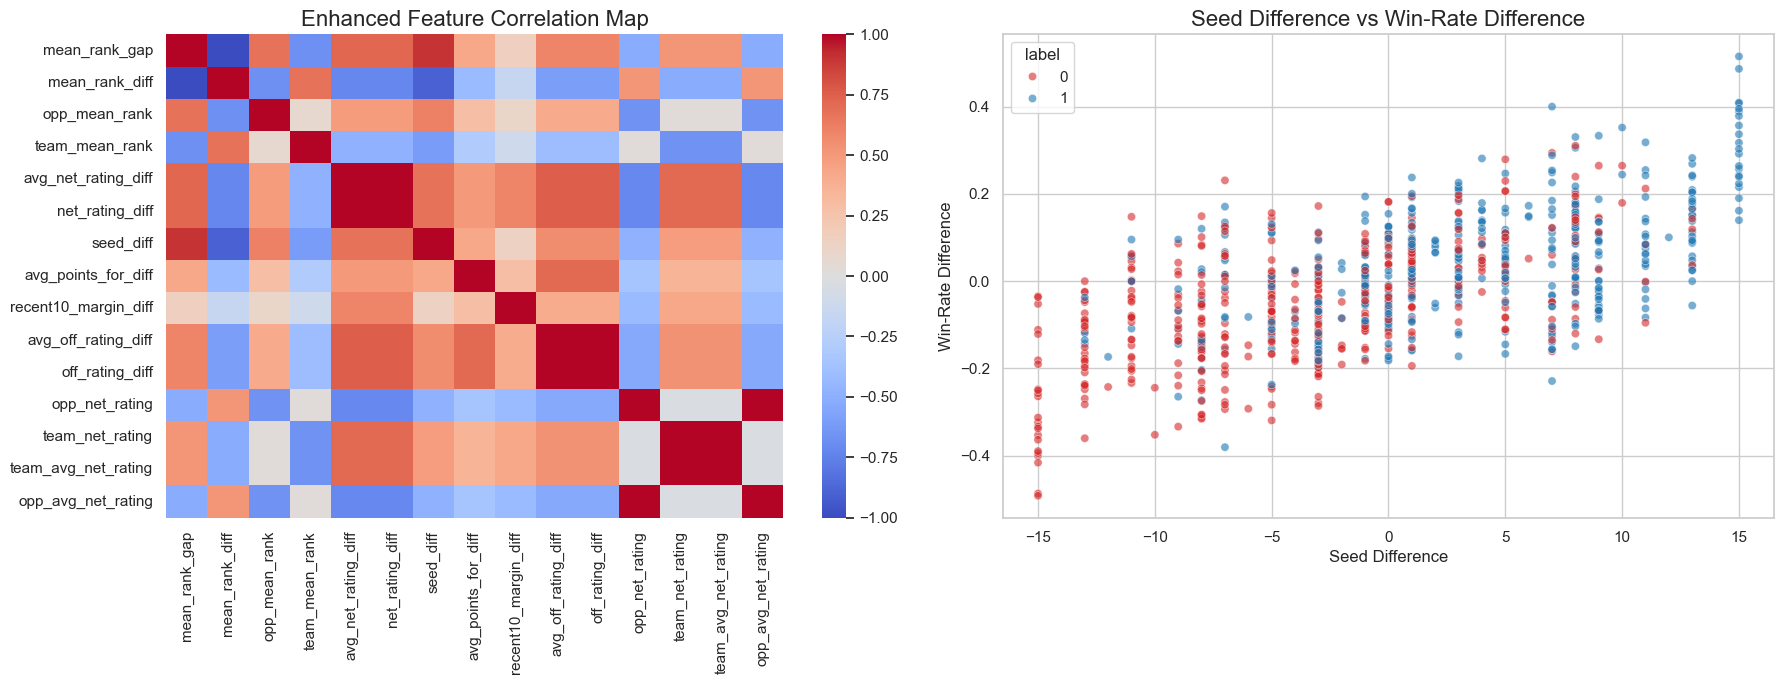

In [8]:
# Use the highest-variance enhanced features so the correlation map stays readable.
top_corr_features = (
    enhanced_df[ENHANCED_FEATURES]
    .var()
    .sort_values(ascending=False)
    .head(15)
    .index
    .tolist()
)

corr_df = enhanced_df[top_corr_features].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_df, cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Enhanced Feature Correlation Map")

scatter_df = enhanced_df.sample(min(900, len(enhanced_df)), random_state=42).copy()
sns.scatterplot(
    data=scatter_df,
    x="seed_diff",
    y="win_pct_diff",
    hue="label",
    alpha=0.6,
    palette={1: "#1f77b4", 0: "#d62728"},
    ax=axes[1],
)
axes[1].set_title("Seed Difference vs Win-Rate Difference")
axes[1].set_xlabel("Seed Difference")
axes[1].set_ylabel("Win-Rate Difference")

plt.tight_layout()
plt.show()


## 4. First pass: simple holdout comparison


In [9]:
# Split chronologically so the model only sees past seasons during training.
portable_train = portable_df.loc[portable_df["Season"] <= 2018].copy()
portable_test = portable_df.loc[portable_df["Season"] > 2018].copy()
enhanced_train = enhanced_df.loc[enhanced_df["Season"] <= 2018].copy()
enhanced_test = enhanced_df.loc[enhanced_df["Season"] > 2018].copy()

# Each entry stores the model plus the train/test matrices it should use.
model_specs = {
    "portable_logreg": (
        LogisticRegression(max_iter=3000),
        portable_train[PORTABLE_FEATURES], portable_train["label"],
        portable_test[PORTABLE_FEATURES], portable_test["label"],
    ),
    "enhanced_logreg": (
        LogisticRegression(max_iter=3000),
        enhanced_train[ENHANCED_FEATURES], enhanced_train["label"],
        enhanced_test[ENHANCED_FEATURES], enhanced_test["label"],
    ),
    "enhanced_rf": (
        RandomForestClassifier(n_estimators=160, max_depth=6, min_samples_leaf=10, random_state=42),
        enhanced_train[ENHANCED_FEATURES], enhanced_train["label"],
        enhanced_test[ENHANCED_FEATURES], enhanced_test["label"],
    ),
    "enhanced_xgb": (
        XGBClassifier(n_estimators=80, max_depth=3, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0, random_state=42, eval_metric="logloss"),
        enhanced_train[ENHANCED_FEATURES], enhanced_train["label"],
        enhanced_test[ENHANCED_FEATURES], enhanced_test["label"],
    ),
}

trained_models = {}
holdout_predictions = {}
holdout_truth = {}
holdout_scores = []
for name, (model, x_train, y_train, x_test, y_test) in model_specs.items():
    # Fit on historical training seasons.
    model.fit(x_train, y_train)
    # Predict probabilities because log loss cares about confidence, not just winner/loser picks.
    probs = model.predict_proba(x_test)[:, 1]
    preds = (probs >= 0.5).astype(int)
    trained_models[name] = model
    holdout_predictions[name] = probs
    holdout_truth[name] = y_test.to_numpy()
    holdout_scores.append({"model": name, "log_loss": log_loss(y_test, probs), "accuracy": accuracy_score(y_test, preds)})

# Baseline: always favor the better seed.
# We use simple probabilities so log loss is defined.
baseline_probs = np.where(
    portable_test["team_seed"] < portable_test["opp_seed"],
    0.75,
    np.where(portable_test["team_seed"] > portable_test["opp_seed"], 0.25, 0.50),
)
baseline_preds = (baseline_probs >= 0.5).astype(int)
holdout_scores.append(
    {
        "model": "seed_favorite_baseline",
        "log_loss": log_loss(portable_test["label"], baseline_probs),
        "accuracy": accuracy_score(portable_test["label"], baseline_preds),
    }
)
holdout_predictions["seed_favorite_baseline"] = baseline_probs
holdout_truth["seed_favorite_baseline"] = portable_test["label"].to_numpy()

# Lower log loss is better.
holdout_df = pd.DataFrame(holdout_scores).sort_values("log_loss").reset_index(drop=True)
best_holdout_model = holdout_df.iloc[0]["model"]
display(holdout_df)


C:\Users\16476\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model,log_loss,accuracy
0,enhanced_rf,0.587210,0.6700
1,enhanced_xgb,0.602604,0.6725
2,portable_logreg,0.612700,0.6800
3,enhanced_logreg,0.631005,0.7050
4,seed_favorite_baseline,0.643621,0.6675


## 4A. Holdout visuals and calibration

The holdout split gives us one clean first comparison:

- bar charts for quick ranking
- calibration curves to show whether the probabilities are sensible


C:\Users\16476\AppData\Local\Temp\ipykernel_67804\2521301924.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=holdout_df, x="model", y="log_loss", ax=axes[0], palette="Blues_r")
C:\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after group

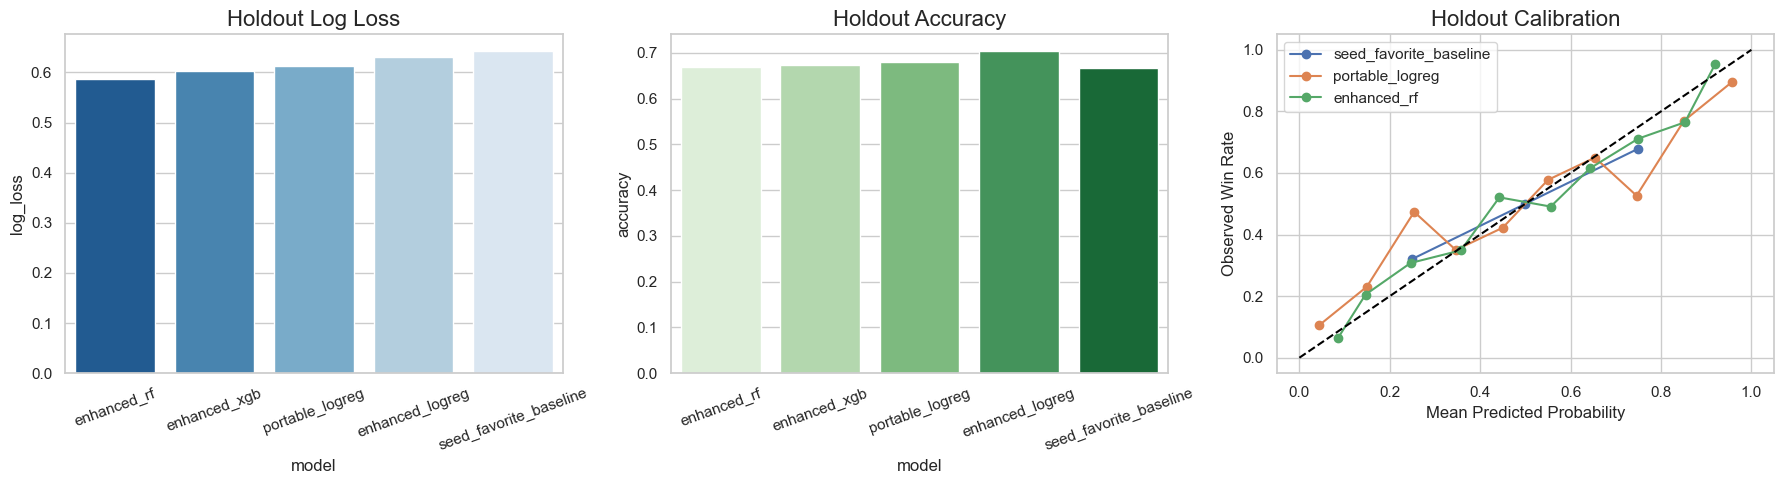

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=holdout_df, x="model", y="log_loss", ax=axes[0], palette="Blues_r")
axes[0].set_title("Holdout Log Loss")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=holdout_df, x="model", y="accuracy", ax=axes[1], palette="Greens")
axes[1].set_title("Holdout Accuracy")
axes[1].tick_params(axis="x", rotation=20)

for model_name in ["seed_favorite_baseline", "portable_logreg", "enhanced_rf"]:
    if model_name not in holdout_predictions:
        continue
    frac_pos, mean_pred = calibration_curve(
        holdout_truth[model_name],
        holdout_predictions[model_name],
        n_bins=10,
    )
    axes[2].plot(mean_pred, frac_pos, marker="o", label=model_name)

axes[2].plot([0, 1], [0, 1], linestyle="--", color="black")
axes[2].set_title("Holdout Calibration")
axes[2].set_xlabel("Mean Predicted Probability")
axes[2].set_ylabel("Observed Win Rate")
axes[2].legend()

plt.tight_layout()
plt.show()


## 5. Rolling backtest across recent seasons


In [11]:
def rolling_backtest(frame, feature_cols, model_factory, seasons):
    # Store one score row per season so we can inspect variability year to year.
    rows = []
    for season in seasons:
        # Train only on seasons before the target year.
        train_df = frame.loc[frame["Season"] < season].copy()
        # Test on that specific season's tournament games.
        test_df = frame.loc[frame["Season"] == season].copy()
        if len(train_df) == 0 or len(test_df) == 0:
            continue
        model = model_factory()
        model.fit(train_df[feature_cols], train_df["label"])
        probs = model.predict_proba(test_df[feature_cols])[:, 1]
        preds = (probs >= 0.5).astype(int)
        rows.append({"season": season, "log_loss": log_loss(test_df["label"], probs), "accuracy": accuracy_score(test_df["label"], preds)})
    return pd.DataFrame(rows)

def rolling_seed_baseline(frame, seasons):
    rows = []
    for season in seasons:
        test_df = frame.loc[frame["Season"] == season].copy()
        if len(test_df) == 0:
            continue
        probs = np.where(
            test_df["team_seed"] < test_df["opp_seed"],
            0.75,
            np.where(test_df["team_seed"] > test_df["opp_seed"], 0.25, 0.50),
        )
        preds = (probs >= 0.5).astype(int)
        rows.append(
            {
                "season": season,
                "log_loss": log_loss(test_df["label"], probs),
                "accuracy": accuracy_score(test_df["label"], preds),
            }
        )
    return pd.DataFrame(rows)

backtest_years = [2019, 2020, 2021, 2022]
backtest_results = {
    "seed_favorite_baseline": rolling_seed_baseline(portable_df, backtest_years),
    "portable_logreg": rolling_backtest(portable_df, PORTABLE_FEATURES, lambda: LogisticRegression(max_iter=3000), backtest_years),
    "enhanced_logreg": rolling_backtest(enhanced_df, ENHANCED_FEATURES, lambda: LogisticRegression(max_iter=3000), backtest_years),
    "enhanced_rf": rolling_backtest(enhanced_df, ENHANCED_FEATURES, lambda: RandomForestClassifier(n_estimators=160, max_depth=6, min_samples_leaf=10, random_state=42), backtest_years),
    "enhanced_xgb": rolling_backtest(enhanced_df, ENHANCED_FEATURES, lambda: XGBClassifier(n_estimators=70, max_depth=3, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0, random_state=42, eval_metric="logloss"), backtest_years),
}

# Average the year-by-year scores so models can be compared side by side.
backtest_summary = []
for model_name, result_df in backtest_results.items():
    backtest_summary.append({"model": model_name, "mean_log_loss": result_df["log_loss"].mean(), "mean_accuracy": result_df["accuracy"].mean()})
backtest_summary_df = pd.DataFrame(backtest_summary).sort_values("mean_log_loss").reset_index(drop=True)
display(backtest_summary_df)


C:\Users\16476\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\16476\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C:\Users\16476\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model,mean_log_loss,mean_accuracy
0,enhanced_rf,0.586618,0.674921
1,enhanced_xgb,0.597303,0.677521
2,portable_logreg,0.611220,0.680009
3,enhanced_logreg,0.632234,0.689959
4,seed_favorite_baseline,0.643576,0.667534


## 5A. Backtest visuals

These visuals help explain what backtesting is doing with past years data.


C:\Users\16476\AppData\Local\Temp\ipykernel_67804\148995540.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=backtest_summary_df, x="model", y="mean_log_loss", ax=axes[0, 0], palette="Blues_r")
C:\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping co

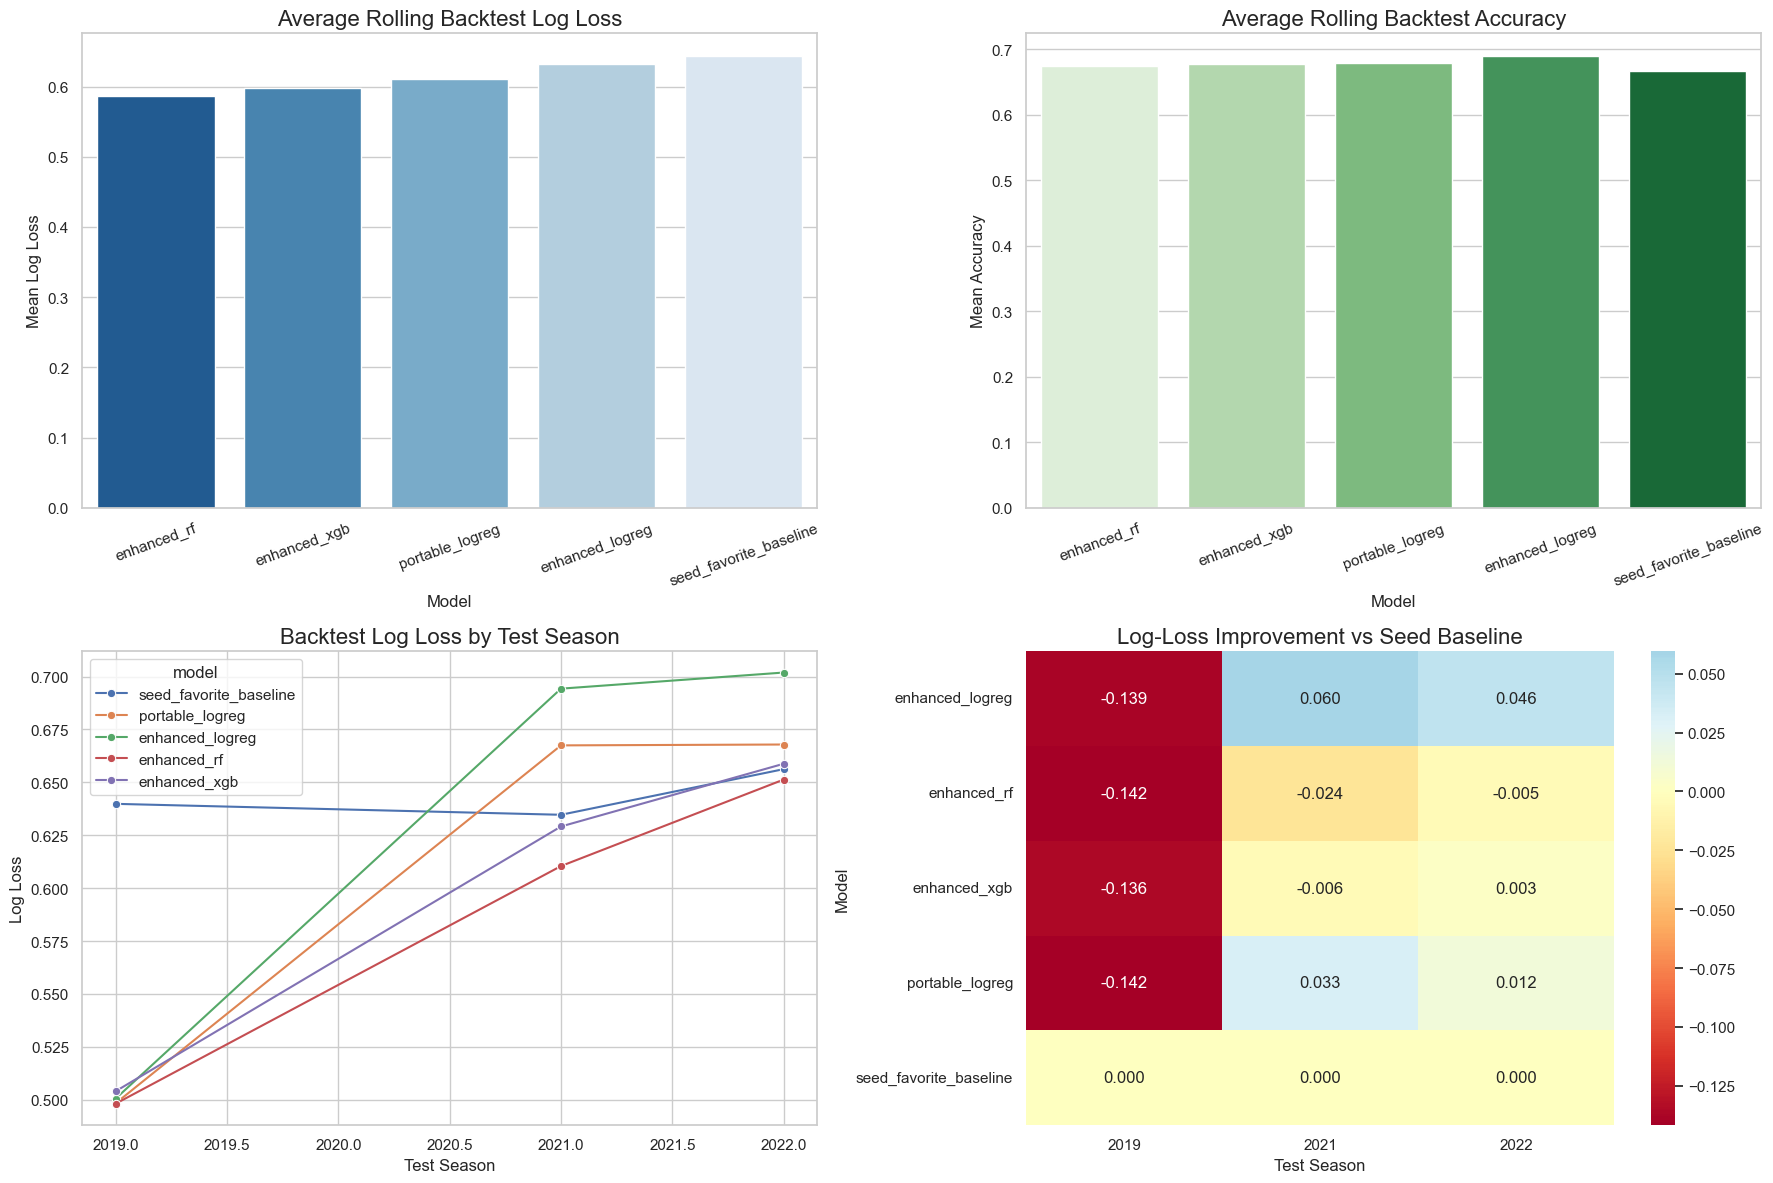

C:\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, 

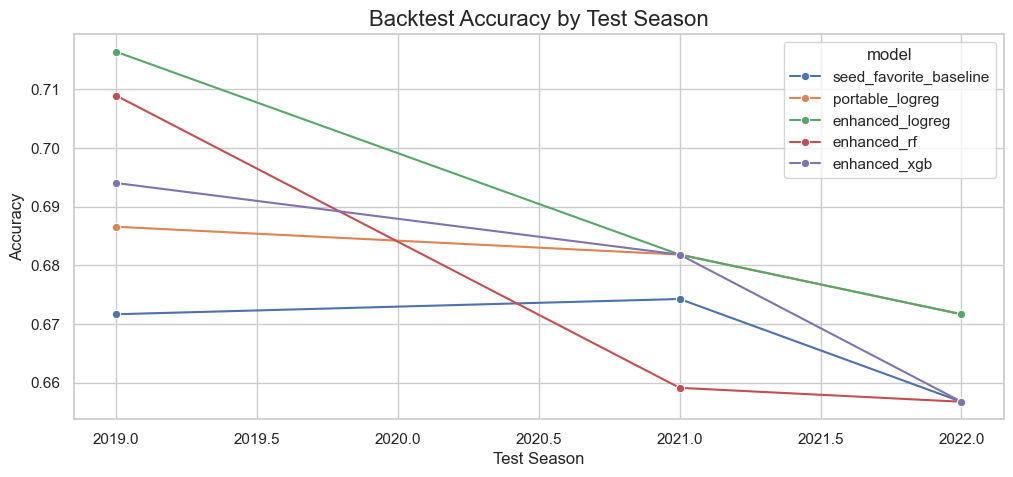

In [12]:
# Put all season-by-season backtest results into one long dataframe for plotting.
backtest_plot_df = pd.concat(
    [result.assign(model=model_name) for model_name, result in backtest_results.items()],
    ignore_index=True,
)

backtest_improvement_df = (
    backtest_plot_df
    .pivot(index="season", columns="model", values="log_loss")
    .subtract(
        backtest_plot_df
        .pivot(index="season", columns="model", values="log_loss")["seed_favorite_baseline"],
        axis=0,
    )
)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(data=backtest_summary_df, x="model", y="mean_log_loss", ax=axes[0, 0], palette="Blues_r")
axes[0, 0].set_title("Average Rolling Backtest Log Loss")
axes[0, 0].set_xlabel("Model")
axes[0, 0].set_ylabel("Mean Log Loss")
axes[0, 0].tick_params(axis="x", rotation=20)

sns.barplot(data=backtest_summary_df, x="model", y="mean_accuracy", ax=axes[0, 1], palette="Greens")
axes[0, 1].set_title("Average Rolling Backtest Accuracy")
axes[0, 1].set_xlabel("Model")
axes[0, 1].set_ylabel("Mean Accuracy")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.lineplot(data=backtest_plot_df, x="season", y="log_loss", hue="model", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Backtest Log Loss by Test Season")
axes[1, 0].set_xlabel("Test Season")
axes[1, 0].set_ylabel("Log Loss")

sns.heatmap(backtest_improvement_df.T, annot=True, fmt=".3f", cmap="RdYlBu", center=0, ax=axes[1, 1])
axes[1, 1].set_title("Log-Loss Improvement vs Seed Baseline")
axes[1, 1].set_xlabel("Test Season")
axes[1, 1].set_ylabel("Model")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(data=backtest_plot_df, x="season", y="accuracy", hue="model", marker="o")
plt.title("Backtest Accuracy by Test Season")
plt.xlabel("Test Season")
plt.ylabel("Accuracy")
plt.show()


## 5B. Example backtest split

This makes the train/test logic concrete by showing one example season split.


In [13]:
example_season = 2022
example_train = enhanced_df.loc[enhanced_df["Season"] < example_season].copy()
example_test = enhanced_df.loc[enhanced_df["Season"] == example_season].copy()

split_summary = pd.DataFrame(
    [
        {
            "test_season": example_season,
            "train_season_start": int(example_train["Season"].min()),
            "train_season_end": int(example_train["Season"].max()),
            "train_rows": len(example_train),
            "test_rows": len(example_test),
        }
    ]
)

display(split_summary)
display(example_test.head())


,test_season,train_season_start,train_season_end,train_rows,test_rows
0,2022,2003,2021,2362,134


,Season,label,team_seed,opp_seed,seed_diff,team_games,opp_games,games_diff,team_wins,opp_wins,wins_diff,team_losses,opp_losses,losses_diff,team_win_pct,opp_win_pct,win_pct_diff,team_rank_pct,opp_rank_pct,rank_pct_diff,team_mean_rank,opp_mean_rank,mean_rank_gap,team_ft_rate,opp_ft_rate,ft_rate_diff,team_three_rate,opp_three_rate,three_rate_diff,team_two_rate,opp_two_rate,two_rate_diff,team_two_pt_pct,opp_two_pt_pct,two_pt_pct_diff,team_three_pt_pct,opp_three_pt_pct,three_pt_pct_diff,team_efg_pct,opp_efg_pct,efg_pct_diff,team_pace,opp_pace,pace_diff,team_off_rating,opp_off_rating,off_rating_diff,team_def_rating,opp_def_rating,def_rating_diff,...,home_win_pct_diff,team_away_win_pct,opp_away_win_pct,away_win_pct_diff,team_neutral_win_pct,opp_neutral_win_pct,neutral_win_pct_diff,mean_rank_diff,team_avg_ft_rate,opp_avg_ft_rate,avg_ft_rate_diff,team_avg_three_rate,opp_avg_three_rate,avg_three_rate_diff,team_avg_two_rate,opp_avg_two_rate,avg_two_rate_diff,team_avg_two_pt_pct,opp_avg_two_pt_pct,avg_two_pt_pct_diff,team_avg_three_pt_pct,opp_avg_three_pt_pct,avg_three_pt_pct_diff,team_avg_efg_pct,opp_avg_efg_pct,avg_efg_pct_diff,team_avg_pace,opp_avg_pace,avg_pace_diff,team_avg_off_rating,opp_avg_off_rating,avg_off_rating_diff,team_avg_def_rating,opp_avg_def_rating,avg_def_rating_diff,team_avg_net_rating,opp_avg_net_rating,avg_net_rating_diff,team_avg_turnover_rate,opp_avg_turnover_rate,avg_turnover_rate_diff,team_avg_ast_rate,opp_avg_ast_rate,avg_ast_rate_diff,team_avg_orb_rate,opp_avg_orb_rate,avg_orb_rate_diff,team_avg_shot_selection_balance,opp_avg_shot_selection_balance,avg_shot_selection_balance_diff
2362,2022,1,12,12,0,33,32,1,20,24,-4,13,8,5,0.606061,0.750000,-0.143939,0.886718,0.842253,0.044465,41.317460,57.142857,15.825397,0.338393,0.378827,-0.040434,0.318291,0.416873,-0.098581,0.681709,0.583127,0.098581,0.518153,0.545751,-0.027598,0.342918,0.326085,0.016834,0.515313,0.526727,-0.011414,68.975758,67.353750,1.622008,103.249818,107.002966,-3.753149,95.869334,97.720878,-1.851544,...,-0.150794,0.272727,0.615385,-0.342657,0.750000,0.600000,0.150000,-15.825397,0.338393,0.378827,-0.040434,0.318291,0.416873,-0.098581,0.681709,0.583127,0.098581,0.518153,0.545751,-0.027598,0.342918,0.326085,0.016834,0.515313,0.526727,-0.011414,68.975758,67.353750,1.622008,103.249818,107.002966,-3.753149,95.869334,97.720878,-1.851544,7.380484,9.282088,-1.901605,0.163618,0.159109,0.004509,0.574064,0.439982,0.134082,0.246995,0.229988,0.017007,-0.020102,0.038046,-0.058148
2363,2022,0,12,12,0,32,33,-1,24,20,4,8,13,-5,0.750000,0.606061,0.143939,0.842253,0.886718,-0.044465,57.142857,41.317460,-15.825397,0.378827,0.338393,0.040434,0.416873,0.318291,0.098581,0.583127,0.681709,-0.098581,0.545751,0.518153,0.027598,0.326085,0.342918,-0.016834,0.526727,0.515313,0.011414,67.353750,68.975758,-1.622008,107.002966,103.249818,3.753149,97.720878,95.869334,1.851544,...,0.150794,0.615385,0.272727,0.342657,0.600000,0.750000,-0.150000,15.825397,0.378827,0.338393,0.040434,0.416873,0.318291,0.098581,0.583127,0.681709,-0.098581,0.545751,0.518153,0.027598,0.326085,0.342918,-0.016834,0.526727,0.515313,0.011414,67.353750,68.975758,-1.622008,107.002966,103.249818,3.753149,97.720878,95.869334,1.851544,9.282088,7.380484,1.901605,0.159109,0.163618,-0.004509,0.439982,0.574064,-0.134082,0.229988,0.246995,-0.017007,0.038046,-0.020102,0.058148
2364,2022,1,16,16,0,30,30,0,18,19,-1,12,11,1,0.600000,0.633333,-0.033333,0.438409,0.347739,0.090670,200.873016,233.142857,32.269841,0.330840,0.391771,-0.060931,0.313405,0.314366,-0.000961,0.686595,0.685634,0.000961,0.493183,0.474871,0.018312,0.321541,0.316522,0.005019,0.486790,0.476104,0.010686,69.996667,72.178000,-2.181333,98.933920,101.953118,-3.019199,93.426139,98.925770,-5.499631,...,0.177778,0.444444,0.538462,-0.094017,1.000000,0.857143,0.142857,-32.269841,0.330840,0.391771,-0.060931,0.313405,0.314366,-0.000961,0.686595,0.685634,0.000961,0.493183,0.474871,0.018312,0.321541,0.316522,0.005019,0.486790,0.476104,0.010686,69.996667,72.178000,-2.181333,

## 5C. What the strongest tree model is using

Tree models are less interpretable than logistic regression, so this plot helps explain what the random forest is leaning on most heavily.


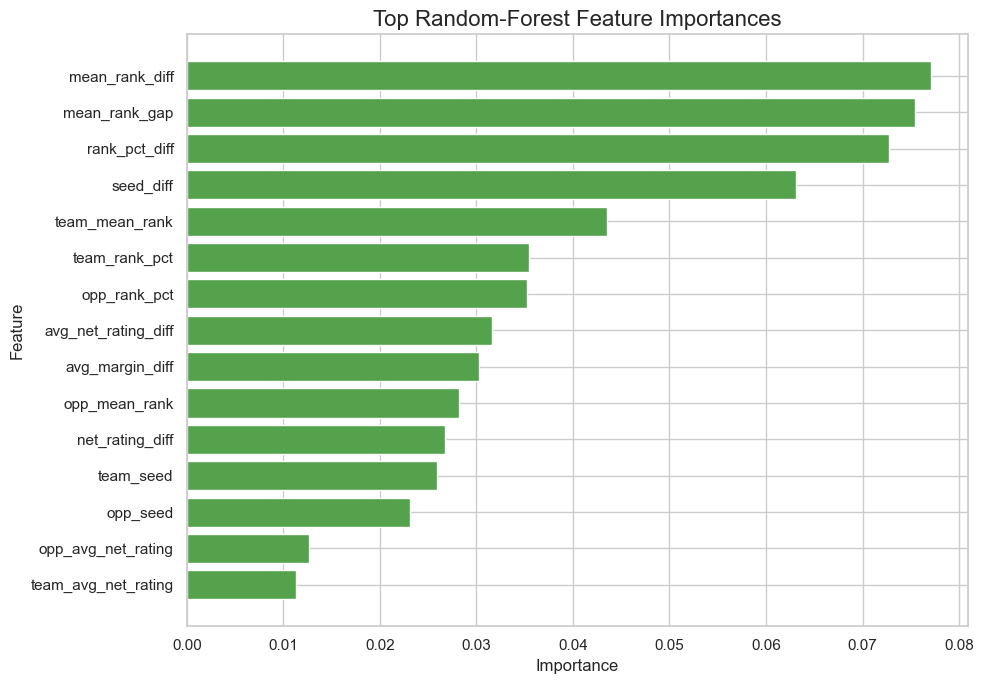

In [14]:
rf_importance_df = (
    pd.DataFrame(
        {
            "feature": ENHANCED_FEATURES,
            "importance": trained_models["enhanced_rf"].feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))
plt.barh(rf_importance_df["feature"], rf_importance_df["importance"], color="#54a24b")
plt.title("Top Random-Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 6. Train the portable live model and bring in 2026 bracket data


In [15]:
# Refit the portable live model on the full historical sample before forecasting 2026.
portable_model = LogisticRegression(max_iter=3000)
portable_model.fit(portable_df[PORTABLE_FEATURES], portable_df["label"])

TEAMRANKINGS_STAT_SPECS = {
    "ft_rate": "free-throw-rate",
    "three_rate": "three-point-rate",
    "two_rate": "two-point-rate",
    "two_pt_pct": "two-point-pct",
    "three_pt_pct": "three-point-pct",
    "efg_pct": "effective-field-goal-pct",
    "pace": "possessions-per-game",
    "off_rating": "offensive-efficiency",
    "def_rating": "defensive-efficiency",
    "turnover_rate": "turnovers-per-possession",
    "ast_rate": "assists-per-fgm",
    "orb_rate": "offensive-rebounding-pct",
}
LIVE_ADVANCED_FEATURES = list(TEAMRANKINGS_STAT_SPECS) + ["net_rating", "shot_selection_balance"]
TEAMRANKINGS_NAME_OVERRIDES = {
    "california baptist": "cal baptist",
    "hawaii": "hawai i",
    "miami fl": "miami",
    "north dakota st": "n dakota st",
    "north dakota state": "n dakota st",
    "northern iowa": "n iowa",
    "prairie view a and m": "prairie view",
    "south florida": "s florida",
}

def parse_record(record_text):
    wins, losses = re.findall(r"\d+", str(record_text))[:2]
    wins = int(wins)
    losses = int(losses)
    games = wins + losses
    win_pct = wins / games if games else 0.5
    return wins, losses, games, win_pct

def normalize_team_name(name):
    cleaned = str(name).lower().replace("&", " and ")
    cleaned = re.sub(r"[^a-z0-9]+", " ", cleaned)
    cleaned = cleaned.replace("saint ", "st ")
    cleaned = re.sub(r"\bstate\b", "st", cleaned)
    cleaned = " ".join(cleaned.split())
    return TEAMRANKINGS_NAME_OVERRIDES.get(cleaned, cleaned)

def fetch_teamrankings_snapshot():
    snapshot = None
    latest_source_year = None
    pct_like_cols = {
        "ft_rate",
        "three_rate",
        "two_rate",
        "two_pt_pct",
        "three_pt_pct",
        "efg_pct",
        "turnover_rate",
        "orb_rate",
    }
    for feature_name, slug in TEAMRANKINGS_STAT_SPECS.items():
        url = f"https://www.teamrankings.com/ncaa-basketball/stat/{slug}"
        html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=30).text
        table = pd.read_html(StringIO(html))[0]
        year_cols = [col for col in table.columns if re.fullmatch(r"\d{4}", str(col))]
        value_col = max(year_cols, key=lambda col: int(str(col)))
        frame = table[["Team", value_col]].copy().rename(columns={"Team": "team", value_col: feature_name})
        raw_values = frame[feature_name].astype(str)
        frame[feature_name] = pd.to_numeric(raw_values.str.replace("%", "", regex=False), errors="coerce")
        if feature_name in pct_like_cols:
            frame[feature_name] = frame[feature_name] / 100
        if feature_name in {"off_rating", "def_rating"}:
            frame[feature_name] = frame[feature_name] * 100
        frame["team_key"] = frame["team"].map(normalize_team_name)
        if snapshot is None:
            snapshot = frame
        else:
            snapshot = snapshot.merge(frame[["team_key", feature_name]], on="team_key", how="outer")
        latest_source_year = value_col
    snapshot["net_rating"] = snapshot["off_rating"] - snapshot["def_rating"]
    snapshot["shot_selection_balance"] = snapshot["three_rate"] - snapshot["ft_rate"]
    snapshot["source_season_label"] = latest_source_year
    snapshot["source_date"] = pd.Timestamp.today().strftime("%Y-%m-%d")
    return snapshot

def load_teamrankings_snapshot():
    if TEAMRANKINGS_PATH.exists():
        snapshot = pd.read_csv(TEAMRANKINGS_PATH)
    else:
        snapshot = fetch_teamrankings_snapshot()
        snapshot.to_csv(TEAMRANKINGS_PATH, index=False)
    pct_like_cols = [
        "ft_rate",
        "three_rate",
        "two_rate",
        "two_pt_pct",
        "three_pt_pct",
        "efg_pct",
        "turnover_rate",
        "orb_rate",
    ]
    if "team_key" not in snapshot.columns:
        snapshot["team_key"] = snapshot["team"].map(normalize_team_name)
    for col in pct_like_cols:
        if col in snapshot.columns and snapshot[col].dropna().median() > 1:
            snapshot[col] = snapshot[col] / 100
    for col in ["off_rating", "def_rating"]:
        if col in snapshot.columns and snapshot[col].dropna().median() < 5:
            snapshot[col] = snapshot[col] * 100
    if "net_rating" not in snapshot.columns:
        snapshot["net_rating"] = snapshot["off_rating"] - snapshot["def_rating"]
    if "shot_selection_balance" not in snapshot.columns:
        snapshot["shot_selection_balance"] = snapshot["three_rate"] - snapshot["ft_rate"]
    return snapshot

# Pull the current men's bracket from Wikipedia because it is much easier to parse than the
# official JavaScript-heavy bracket pages.
response = requests.get(BRACKET_URL, headers={"User-Agent": "Mozilla/5.0"}, timeout=30)
response.raise_for_status()
tables = pd.read_html(StringIO(response.text))

# The four region tables are the tables with seed/school/record columns and 16-18 rows.
region_indices = [idx for idx, table in enumerate(tables) if {"Seed", "School", "Conference", "Record"}.issubset(set(map(str, table.columns))) and 16 <= len(table) <= 18][:4]
region_names = ["East", "West", "South", "Midwest"]
regions = {}
for region_name, idx in zip(region_names, region_indices):
    df = tables[idx][["Seed", "School", "Record"]].copy()
    df["seed"] = df["Seed"].astype(str).str.extract(r"(\d+)").astype(int)
    df["team"] = df["School"].astype(str)
    parsed_records = df["Record"].map(parse_record)
    df["wins"] = parsed_records.map(lambda x: x[0])
    df["losses"] = parsed_records.map(lambda x: x[1])
    df["games"] = parsed_records.map(lambda x: x[2])
    df["win_pct"] = parsed_records.map(lambda x: x[3])
    df["region"] = region_name
    df["team_key"] = df["team"].map(normalize_team_name)
    regions[region_name] = df[["region", "seed", "team", "team_key", "Record", "wins", "losses", "games", "win_pct"]].rename(columns={"Record": "record"})

teamrankings = load_teamrankings_snapshot()
missing_teamrankings_matches = 0
for region_name in region_names:
    regions[region_name] = regions[region_name].merge(teamrankings[["team_key"] + LIVE_ADVANCED_FEATURES], on="team_key", how="left")
    missing_teamrankings_matches += regions[region_name]["off_rating"].isna().sum()
    for col in LIVE_ADVANCED_FEATURES:
        regions[region_name][col] = regions[region_name][col].fillna(teamrankings[col].median())

# Bring in stronger current-year team strength via the local KenPom snapshot.
kenpom = pd.read_csv(KENPOM_PATH)
max_live_rank = kenpom["kenpom_rank"].max()
kenpom["rank_pct"] = 1 - ((kenpom["kenpom_rank"] - 1) / (max_live_rank - 1))
missing_kenpom_matches = 0
for region_name in region_names:
    regions[region_name] = regions[region_name].merge(kenpom[["team", "kenpom_rank", "kenpom_adj_em", "rank_pct"]], on="team", how="left")
    missing_kenpom_matches += regions[region_name]["kenpom_adj_em"].isna().sum()
    regions[region_name]["rank_pct"] = regions[region_name]["rank_pct"].fillna(0.5)
    regions[region_name]["kenpom_rank"] = regions[region_name]["kenpom_rank"].fillna(kenpom["kenpom_rank"].median())
    regions[region_name]["kenpom_adj_em"] = regions[region_name]["kenpom_adj_em"].fillna(kenpom["kenpom_adj_em"].median())

print("TeamRankings rows:", len(teamrankings))
print("Missing TeamRankings matches before fill:", missing_teamrankings_matches)
print("KenPom rows:", len(kenpom))
print("Missing KenPom matches before fill:", missing_kenpom_matches)


TeamRankings rows: 365
Missing TeamRankings matches before fill: 0
KenPom rows: 68
Missing KenPom matches before fill: 0


## 7. Blend the live ML model with KenPom


In [16]:
SEED_ORDER = [1, 16, 8, 9, 5, 12, 4, 13, 6, 11, 3, 14, 7, 10, 2, 15]

def ordered_unique(values):
    seen = set()
    out = []
    for value in values:
        if value not in seen:
            seen.add(value)
            out.append(value)
    return out

def parse_play_in_table(table):
    # The First Four tables are messy, so we flatten them and keep only the meaningful cells.
    header = str(table.iloc[0, 1])
    region = re.search(r"([A-Za-z]+) Regional$", header).group(1)
    flat = [str(v) for v in table.iloc[2:].to_numpy().flatten() if pd.notna(v)]
    seed = int(float(next(v for v in flat if re.fullmatch(r"\d+(?:\.0)?", v))))
    team_names = []
    for value in flat:
        if value in {"CBS", "TBS", "TNT", "truTV"} or re.fullmatch(r"\d+(?:\.0)?", value) or re.search(r"\d{1,2}:\d{2}", value):
            continue
        team_names.append(value)
    return {"region": region, "seed": seed, "teams": ordered_unique(team_names)[:2]}

# These are the four play-in tables shown on the bracket page.
play_in_indices = [idx for idx, table in enumerate(tables) if table.shape == (6, 5)][:4]
play_in_games = [parse_play_in_table(tables[idx]) for idx in play_in_indices]

def clip_prob(p):
    return float(np.clip(p, 1e-6, 1 - 1e-6))

def build_live_feature_row(team_a, team_b):
    # These are the live-available features used by the portable model.
    row = {
        "team_seed": team_a["seed"],
        "opp_seed": team_b["seed"],
        "seed_diff": team_b["seed"] - team_a["seed"],
        "team_games": team_a["games"],
        "opp_games": team_b["games"],
        "games_diff": team_a["games"] - team_b["games"],
        "team_wins": team_a["wins"],
        "opp_wins": team_b["wins"],
        "wins_diff": team_a["wins"] - team_b["wins"],
        "team_losses": team_a["losses"],
        "opp_losses": team_b["losses"],
        "losses_diff": team_b["losses"] - team_a["losses"],
        "team_win_pct": team_a["win_pct"],
        "opp_win_pct": team_b["win_pct"],
        "win_pct_diff": team_a["win_pct"] - team_b["win_pct"],
        "team_rank_pct": team_a["rank_pct"],
        "opp_rank_pct": team_b["rank_pct"],
        "rank_pct_diff": team_a["rank_pct"] - team_b["rank_pct"],
        "team_mean_rank": team_a["kenpom_rank"],
        "opp_mean_rank": team_b["kenpom_rank"],
        "mean_rank_gap": team_b["kenpom_rank"] - team_a["kenpom_rank"],
    }
    for col in LIVE_ADVANCED_FEATURES:
        row[f"team_{col}"] = team_a[col]
        row[f"opp_{col}"] = team_b[col]
        row[f"{col}_diff"] = team_a[col] - team_b[col]
    return pd.DataFrame([row])

def portable_matchup_prob(team_a, team_b):
    # Build the same feature layout that the portable logistic regression saw in training.
    x = build_live_feature_row(team_a, team_b)
    return float(portable_model.predict_proba(x[PORTABLE_FEATURES])[:, 1][0])

def kenpom_matchup_prob(team_a, team_b, scale=11.0):
    if pd.isna(team_a["kenpom_adj_em"]) or pd.isna(team_b["kenpom_adj_em"]):
        return 0.5
    diff = team_a["kenpom_adj_em"] - team_b["kenpom_adj_em"]
    return float(1 / (1 + np.exp(-(diff / scale))))

def blended_matchup_prob(team_a, team_b, ml_weight=0.65, kp_weight=0.35):
    # Blend on the log-odds scale so the two probabilities combine more naturally.
    ml_prob = clip_prob(portable_matchup_prob(team_a, team_b))
    kp_prob = clip_prob(kenpom_matchup_prob(team_a, team_b))
    blend_logit = ml_weight * np.log(ml_prob / (1 - ml_prob)) + kp_weight * np.log(kp_prob / (1 - kp_prob))
    blend_prob = float(1 / (1 + np.exp(-blend_logit)))
    return ml_prob, kp_prob, blend_prob

def pick_winner(team_a, team_b, round_name, region_name):
    # Return both the raw probabilities and the chosen winner so we can inspect the model's reasoning.
    ml_prob, kp_prob, blend_prob = blended_matchup_prob(team_a, team_b)
    winner = team_a if blend_prob >= 0.5 else team_b
    loser = team_b if blend_prob >= 0.5 else team_a
    return {"round": round_name, "region": region_name, "team_1": team_a["team"], "seed_1": team_a["seed"], "team_2": team_b["team"], "seed_2": team_b["seed"], "portable_ml_prob_team_1": round(ml_prob, 4), "kenpom_prob_team_1": round(kp_prob, 4), "blended_prob_team_1": round(blend_prob, 4), "winner": winner["team"], "winner_seed": winner["seed"], "loser": loser["team"]}


## 8. Deterministic bracket


In [17]:
# Work on copies so the original region tables stay unchanged.
region_frames = {name: df.copy() for name, df in regions.items()}
deterministic_results = []
for play_in in play_in_games:
    # Resolve play-in games first so every region ends up with a normal 16-team bracket.
    region_name = play_in["region"]
    seed = play_in["seed"]
    region_df = region_frames[region_name]
    candidates = region_df.loc[(region_df["seed"] == seed) & (region_df["team"].isin(play_in["teams"]))].reset_index(drop=True)
    team_a = candidates.iloc[0].to_dict()
    team_b = candidates.iloc[1].to_dict()
    result = pick_winner(team_a, team_b, "First Four", region_name)
    deterministic_results.append(result)
    winner_name = result["winner"]
    region_frames[region_name] = region_df.loc[~((region_df["seed"] == seed) & (region_df["team"] != winner_name))].reset_index(drop=True)

def simulate_region_deterministic(region_df):
    # Build the round-of-64 seed order, then repeatedly collapse winners into the next round.
    region_name = region_df["region"].iloc[0]
    lookup = {seed: region_df.loc[region_df["seed"] == seed].iloc[0].to_dict() for seed in SEED_ORDER}
    current = [lookup[seed] for seed in SEED_ORDER]
    results = []
    for round_name in ["Round of 64", "Round of 32", "Sweet 16", "Elite 8"]:
        next_round = []
        for idx in range(0, len(current), 2):
            team_a = current[idx]
            team_b = current[idx + 1]
            result = pick_winner(team_a, team_b, round_name, region_name)
            results.append(result)
            next_round.append(team_a if result["winner"] == team_a["team"] else team_b)
        current = next_round
    return current[0], results

# Simulate each region independently up through the Elite Eight.
regional_champions = {}
for region_name in region_names:
    champion, rows = simulate_region_deterministic(region_frames[region_name])
    regional_champions[region_name] = champion
    deterministic_results.extend(rows)
ff1 = pick_winner(regional_champions["East"], regional_champions["West"], "Final Four", "National")
ff2 = pick_winner(regional_champions["South"], regional_champions["Midwest"], "Final Four", "National")
deterministic_results.extend([ff1, ff2])
finalist_1 = regional_champions["East"] if ff1["winner"] == regional_champions["East"]["team"] else regional_champions["West"]
finalist_2 = regional_champions["South"] if ff2["winner"] == regional_champions["South"]["team"] else regional_champions["Midwest"]
title_game = pick_winner(finalist_1, finalist_2, "Championship", "National")
deterministic_results.append(title_game)
deterministic_df = pd.DataFrame(deterministic_results)
print("Deterministic champion:", title_game["winner"])


Deterministic champion: Duke


## 8A. Show the bracket game-by-game with odds

Instead of only showing the champion, this section prints the actual predicted bracket path:

- each matchup
- each round
- each game's blended win probability


In [18]:
# Sort the bracket results in a natural tournament order.
round_order = ["First Four", "Round of 64", "Round of 32", "Sweet 16", "Elite 8", "Final Four", "Championship"]
deterministic_df["round"] = pd.Categorical(deterministic_df["round"], categories=round_order, ordered=True)
deterministic_df = deterministic_df.sort_values(["round", "region", "seed_1", "seed_2"]).reset_index(drop=True)

# Show round-by-round game tables.
for round_name in round_order:
    round_df = deterministic_df.loc[deterministic_df["round"] == round_name].copy()
    if len(round_df) == 0:
        continue
    print(f"\n{round_name}")
    display(
        round_df[
            [
                "region",
                "team_1",
                "seed_1",
                "team_2",
                "seed_2",
                "portable_ml_prob_team_1",
                "kenpom_prob_team_1",
                "blended_prob_team_1",
                "winner",
            ]
        ].reset_index(drop=True)
    )



First Four


,region,team_1,seed_1,team_2,seed_2,portable_ml_prob_team_1,kenpom_prob_team_1,blended_prob_team_1,winner
0,Midwest,Miami (OH),11,SMU,11,0.2684,0.2904,0.2759,SMU
1,Midwest,UMBC,16,Howard,16,0.6036,0.5345,0.5798,UMBC
2,South,Prairie View A&M,16,Lehigh,16,0.5344,0.4927,0.5199,Prairie View A&M
3,West,Texas,11,NC State,11,0.5202,0.4870,0.5086,Texas



Round of 64


,region,team_1,seed_1,team_2,seed_2,portable_ml_prob_team_1,kenpom_prob_team_1,blended_prob_team_1,winner
0,East,Duke,1,Siena,16,0.9692,0.9765,0.9720,Duke
1,East,UConn,2,Furman,15,0.9531,0.9378,0.9482,UConn
2,East,Michigan State,3,North Dakota State,14,0.8267,0.8916,0.8524,Michigan State
3,East,Kansas,4,California Baptist,13,0.7845,0.8425,0.8064,Kansas
4,East,St. John's,5,Northern Iowa,12,0.6945,0.7828,0.7276,St. John's
5,East,Louisville,6,South Florida,11,0.7176,0.6944,0.7096,Louisville
6,East,UCLA,7,UCF,10,0.6987,0.6463,0.6808,UCLA
7,East,Ohio State,8,TCU,9,0.6214,0.6041,0.6154,Ohio State
8,Midwest,Michigan,1,UMBC,16,0.9632,0.9726,0.9668,Michigan
9,Midwest,Iowa State,2,Tennessee State,15,0.9704,0.9575,0.9664,Iowa State



Round of 32


...

,region,team_1,seed_1,team_2,seed_2,portable_ml_prob_team_1,kenpom_prob_team_1,blended_prob_team_1,winner
0,East,Duke,1,UConn,2,0.6525,0.7316,0.6815,Duke
1,Midwest,Michigan,1,Iowa State,2,0.4648,0.6154,0.5182,Michigan
2,South,Florida,1,Houston,2,0.4752,0.5082,0.4868,Houston
3,West,Arizona,1,Purdue,2,0.5328,0.6427,0.5722,Arizona



Final Four


,region,team_1,seed_1,team_2,seed_2,portable_ml_prob_team_1,kenpom_prob_team_1,blended_prob_team_1,winner
0,National,Duke,1,Arizona,1,0.5566,0.5282,0.5467,Duke
1,National,Houston,2,Michigan,1,0.5550,0.4066,0.5028,Houston



Championship


,region,team_1,seed_1,team_2,seed_2,portable_ml_prob_team_1,kenpom_prob_team_1,blended_prob_team_1,winner
0,National,Duke,1,Houston,2,0.5198,0.6218,0.5561,Duke


## 8B. Region winner and title-path visuals

These quick visuals make the bracket output easier to scan than raw tables alone.


In [19]:
# Regional champions plus the title-game path.
path_df = deterministic_df.loc[
    deterministic_df["round"].isin(["Elite 8", "Final Four", "Championship"]),
    ["round", "region", "team_1", "team_2", "winner", "blended_prob_team_1"],
].copy()
display(path_df.reset_index(drop=True))

# Plot title odds for the top teams after the Monte Carlo section later.


,round,region,team_1,team_2,winner,blended_prob_team_1
0,Elite 8,East,Duke,UConn,Duke,0.6815
1,Elite 8,Midwest,Michigan,Iowa State,Michigan,0.5182
2,Elite 8,South,Florida,Houston,Houston,0.4868
3,Elite 8,West,Arizona,Purdue,Arizona,0.5722
4,Final Four,National,Duke,Arizona,Duke,0.5467
5,Final Four,National,Houston,Michigan,Houston,0.5028
6,Championship,National,Duke,Houston,Duke,0.5561


## 8C. Full bracket board

This creates a cleaner visual bracket board by region so you can see the predicted path through each side of the tournament.


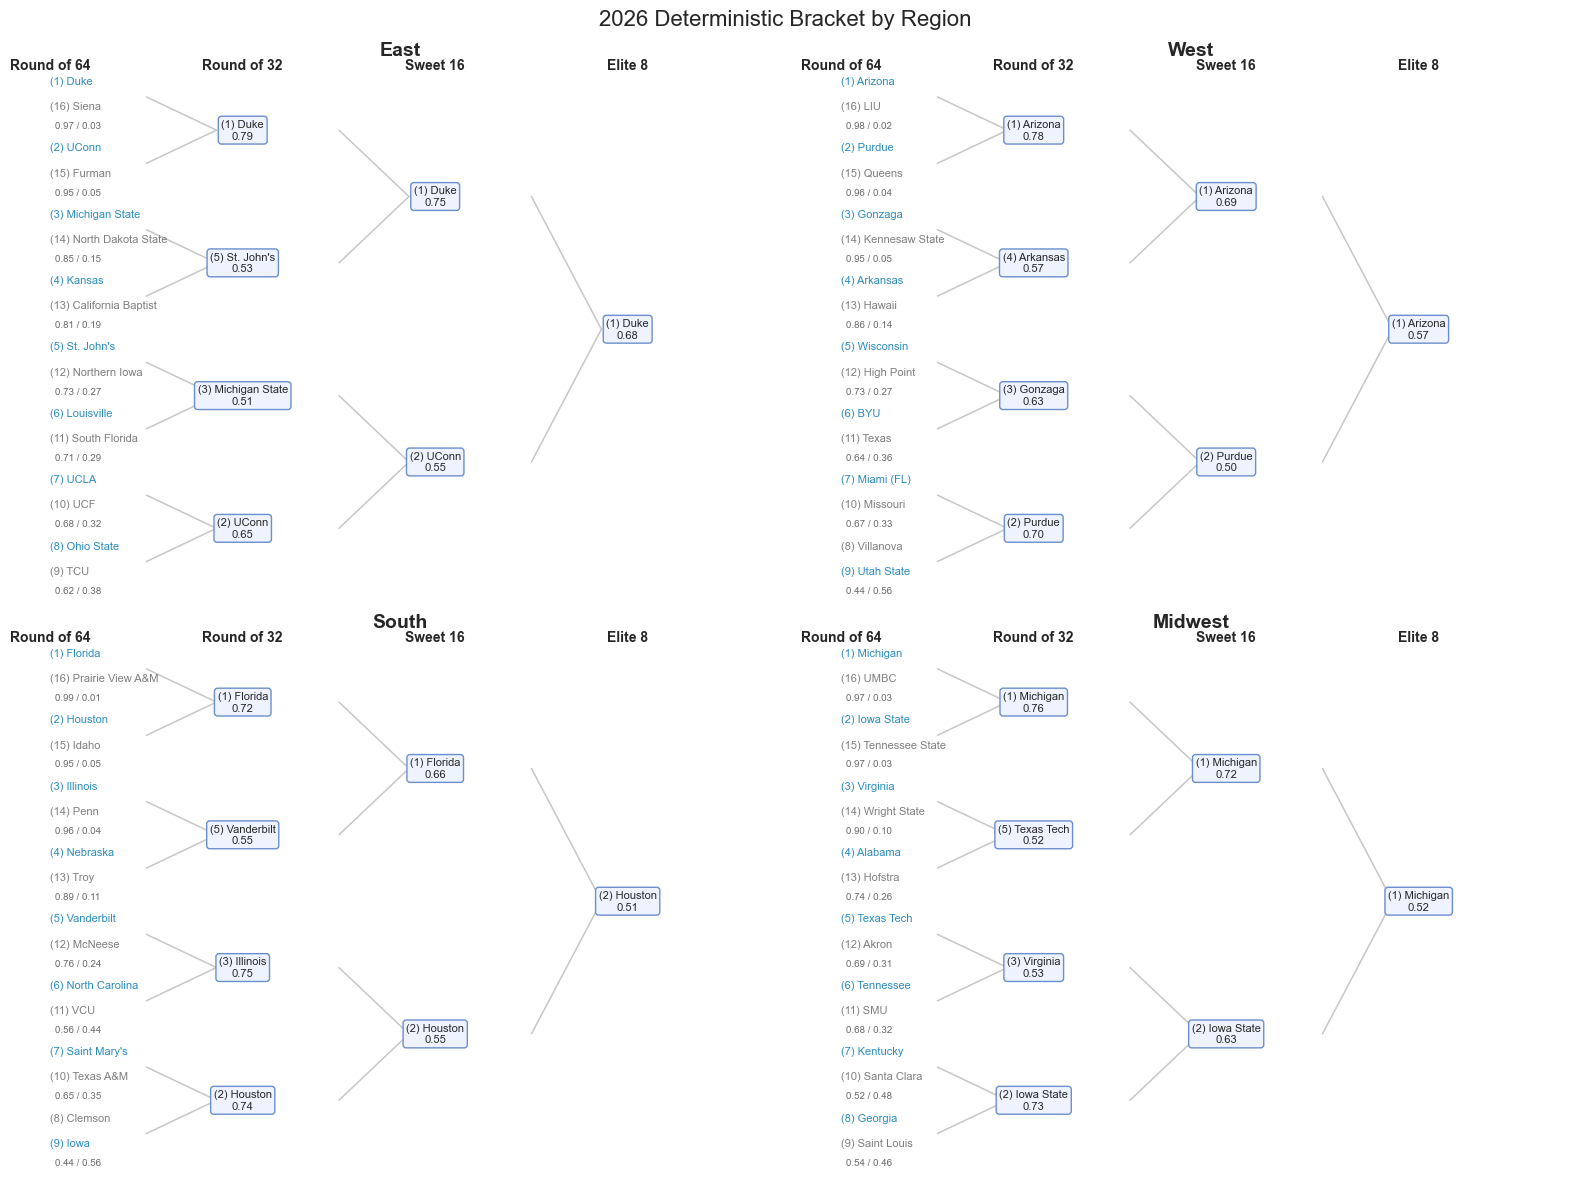

,round,team_1,team_2,winner,blended_prob_team_1
0,Final Four,Duke,Arizona,Duke,0.5467
1,Final Four,Houston,Michigan,Houston,0.5028
2,Championship,Duke,Houston,Duke,0.5561


In [20]:
def draw_region_bracket(ax, region_name, region_results):
    round_x = {"Round of 64": 0.05, "Round of 32": 1.15, "Sweet 16": 2.25, "Elite 8": 3.35}
    y_positions = {"Round of 64": [15, 13, 11, 9, 7, 5, 3, 1], "Round of 32": [14, 10, 6, 2], "Sweet 16": [12, 4], "Elite 8": [8]}

    ax.set_title(region_name, fontsize=14, fontweight="bold")
    ax.set_xlim(-0.1, 4.2)
    ax.set_ylim(0, 16)
    ax.axis("off")

    for round_name, x in round_x.items():
        ax.text(x, 15.75, round_name, ha="center", va="bottom", fontsize=10, fontweight="bold")

    round64 = region_results.loc[region_results["round"] == "Round of 64"].reset_index(drop=True)
    for idx, (_, row) in enumerate(round64.iterrows()):
        y = y_positions["Round of 64"][idx]
        prob_team_1 = row["blended_prob_team_1"]
        prob_team_2 = 1 - prob_team_1
        color_1 = "#2b8cbe" if row["winner"] == row["team_1"] else "#7f7f7f"
        color_2 = "#2b8cbe" if row["winner"] == row["team_2"] else "#7f7f7f"
        ax.text(round_x["Round of 64"], y + 0.38, f"({row['seed_1']}) {row['team_1']}", fontsize=8, ha="left", color=color_1)
        ax.text(round_x["Round of 64"], y - 0.38, f"({row['seed_2']}) {row['team_2']}", fontsize=8, ha="left", color=color_2)
        ax.text(round_x["Round of 64"] + 0.03, y - 0.95, f"{prob_team_1:.2f} / {prob_team_2:.2f}", fontsize=7, ha="left", color="dimgray")

    connector_map = {
        "Round of 32": y_positions["Round of 64"],
        "Sweet 16": y_positions["Round of 32"],
        "Elite 8": y_positions["Sweet 16"],
    }

    for round_name in ["Round of 32", "Sweet 16", "Elite 8"]:
        subset = region_results.loc[region_results["round"] == round_name].reset_index(drop=True)
        source_positions = connector_map[round_name]
        for idx, (_, row) in enumerate(subset.iterrows()):
            y = y_positions[round_name][idx]
            x = round_x[round_name]

            source_top = source_positions[2 * idx]
            source_bottom = source_positions[2 * idx + 1]
            prev_round_name = list(round_x.keys())[list(round_x.keys()).index(round_name) - 1]
            prev_x = round_x[prev_round_name] + 0.55

            ax.plot([prev_x, x - 0.15], [source_top, y], color="#c7c7c7", lw=1.1)
            ax.plot([prev_x, x - 0.15], [source_bottom, y], color="#c7c7c7", lw=1.1)

            winner_prob = row["blended_prob_team_1"] if row["winner"] == row["team_1"] else 1 - row["blended_prob_team_1"]
            ax.text(
                x,
                y,
                f"({row['winner_seed']}) {row['winner']}\n{winner_prob:.2f}",
                fontsize=8,
                ha="center",
                va="center",
                bbox=dict(boxstyle="round,pad=0.28", facecolor="#eef3ff", edgecolor="#6b8ecf"),
            )


region_fig, region_axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, region_name in zip(region_axes.flatten(), ["East", "West", "South", "Midwest"]):
    region_results = deterministic_df.loc[
        (deterministic_df["region"] == region_name)
        & (deterministic_df["round"].isin(["Round of 64", "Round of 32", "Sweet 16", "Elite 8"]))
    ].copy()
    draw_region_bracket(ax, region_name, region_results)

plt.suptitle("2026 Deterministic Bracket by Region", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

final_four_df = deterministic_df.loc[
    deterministic_df["round"].isin(["Final Four", "Championship"]),
    ["round", "team_1", "team_2", "winner", "blended_prob_team_1"],
].reset_index(drop=True)
display(final_four_df)


## 8D. SHAP explanations for Duke and Michigan

The bracket picks tell us **what** the model is doing.

SHAP helps explain **why** the portable live model leans toward one side in each predicted Duke and Michigan matchup.

Teaching note:
- these SHAP values explain the portable ML model
- the final bracket still blends that model with KenPom
- so this section is best read as "what the ML side of the forecast is seeing"
- the second heatmap zooms in on the advanced TeamRankings-style features only


Duke path explanations


,round,opponent,portable_prob_for_team,kenpom_prob_for_team,blended_prob_for_team,predicted_winner
0,Round of 64,Siena,0.969,0.977,0.972,Duke
1,Round of 32,Ohio State,0.780,0.820,0.794,Duke
2,Sweet 16,St. John's,0.735,0.765,0.746,Duke
3,Elite 8,UConn,0.652,0.732,0.681,Duke
4,Final Four,Arizona,0.557,0.528,0.547,Duke
5,Championship,Houston,0.520,0.622,0.556,Duke


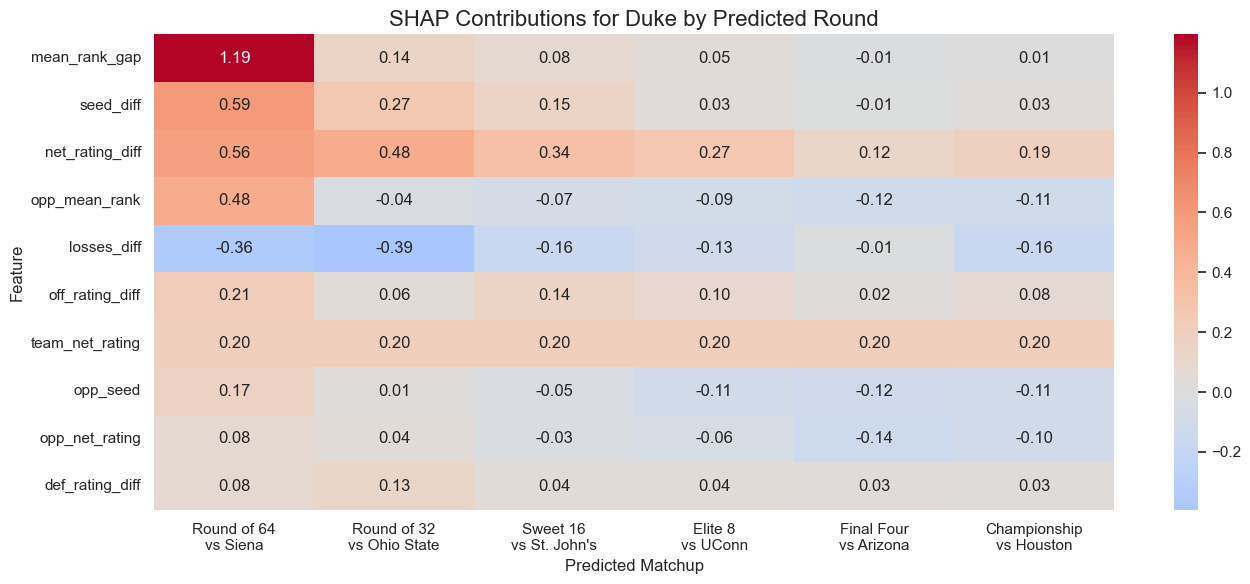

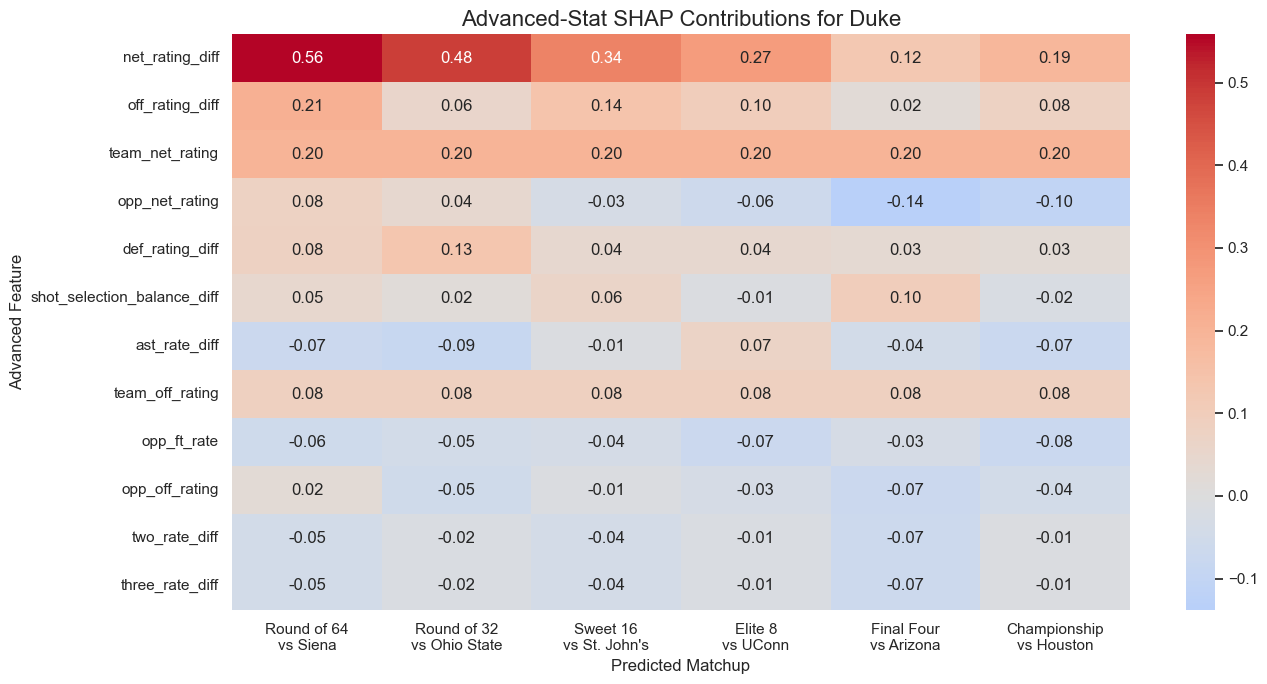

Michigan path explanations


,round,opponent,portable_prob_for_team,kenpom_prob_for_team,blended_prob_for_team,predicted_winner
0,Round of 64,UMBC,0.963,0.973,0.967,Michigan
1,Round of 32,Georgia,0.719,0.826,0.761,Michigan
2,Sweet 16,Texas Tech,0.696,0.755,0.717,Michigan
3,Elite 8,Iowa State,0.465,0.615,0.518,Michigan
4,Final Four,Houston,0.445,0.593,0.497,Houston


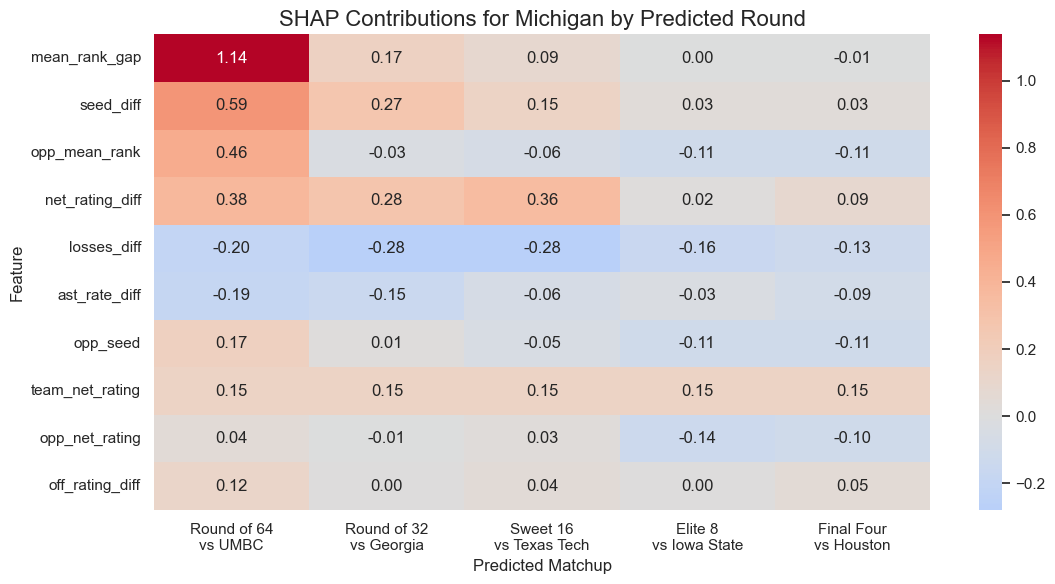

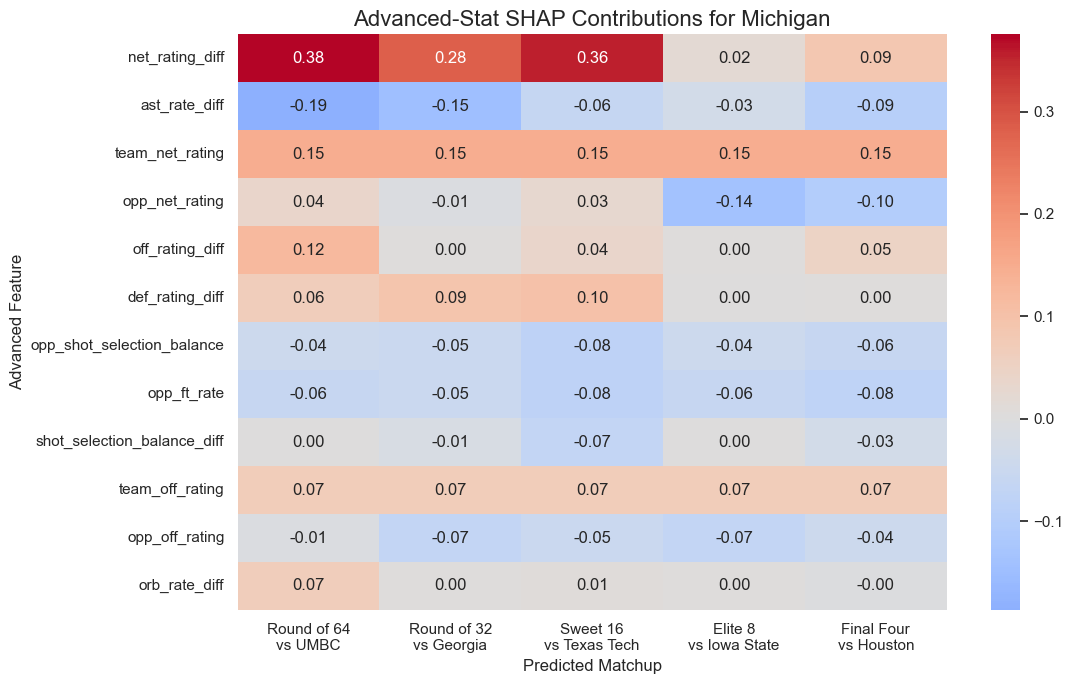

In [21]:
if HAS_SHAP:
    # Use a small background sample so the explainer stays lightweight in a workshop notebook.
    shap_background = portable_df[PORTABLE_FEATURES].sample(min(300, len(portable_df)), random_state=42)
    shap_explainer = shap.LinearExplainer(portable_model, shap_background)

    # Build a lookup for every 2026 team in the field so we can reconstruct matchup rows from either team's perspective.
    live_team_lookup = {row["team"]: row.to_dict() for _, df in regions.items() for _, row in df.iterrows()}
    advanced_shap_features = [
        feature
        for feature in PORTABLE_FEATURES
        if any(
            token in feature
            for token in [
                "ft_rate",
                "three_rate",
                "two_rate",
                "two_pt_pct",
                "three_pt_pct",
                "efg_pct",
                "pace",
                "off_rating",
                "def_rating",
                "net_rating",
                "turnover_rate",
                "ast_rate",
                "orb_rate",
                "shot_selection_balance",
            ]
        )
    ]

    def explain_team_path(target_team):
        team_games = deterministic_df.loc[
            (deterministic_df["team_1"] == target_team) | (deterministic_df["team_2"] == target_team)
        ].copy().reset_index(drop=True)

        if len(team_games) == 0:
            print(f"No deterministic path found for {target_team}.")
            return

        summary_rows = []
        shap_rows = []
        round_labels = []

        for _, game in team_games.iterrows():
            opponent = game["team_2"] if game["team_1"] == target_team else game["team_1"]
            team_a = live_team_lookup[target_team]
            team_b = live_team_lookup[opponent]

            x = build_live_feature_row(team_a, team_b)
            portable_prob = float(portable_model.predict_proba(x[PORTABLE_FEATURES])[:, 1][0])
            kenpom_prob = float(kenpom_matchup_prob(team_a, team_b))
            _, _, blended_prob = blended_matchup_prob(team_a, team_b)
            predicted_winner = target_team if blended_prob >= 0.5 else opponent

            shap_exp = shap_explainer(x[PORTABLE_FEATURES])[0]
            shap_rows.append(shap_exp.values)
            round_labels.append(f"{game['round']}\nvs {opponent}")

            summary_rows.append(
                {
                    "round": game["round"],
                    "opponent": opponent,
                    "portable_prob_for_team": round(portable_prob, 3),
                    "kenpom_prob_for_team": round(kenpom_prob, 3),
                    "blended_prob_for_team": round(blended_prob, 3),
                    "predicted_winner": predicted_winner,
                }
            )

        summary_df = pd.DataFrame(summary_rows)
        display(summary_df)

        shap_matrix = pd.DataFrame(
            np.array(shap_rows).T,
            index=PORTABLE_FEATURES,
            columns=round_labels,
        )

        top_features = (
            shap_matrix.abs()
            .max(axis=1)
            .sort_values(ascending=False)
            .head(10)
            .index
        )

        plt.figure(figsize=(max(10, 2.3 * len(round_labels)), 6))
        sns.heatmap(
            shap_matrix.loc[top_features],
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
        )
        plt.title(f"SHAP Contributions for {target_team} by Predicted Round")
        plt.xlabel("Predicted Matchup")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

        advanced_features = (
            shap_matrix.loc[advanced_shap_features]
            .abs()
            .max(axis=1)
            .sort_values(ascending=False)
            .head(12)
            .index
        )

        plt.figure(figsize=(max(10, 2.3 * len(round_labels)), 7))
        sns.heatmap(
            shap_matrix.loc[advanced_features],
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
        )
        plt.title(f"Advanced-Stat SHAP Contributions for {target_team}")
        plt.xlabel("Predicted Matchup")
        plt.ylabel("Advanced Feature")
        plt.tight_layout()
        plt.show()

    print("Duke path explanations")
    explain_team_path("Duke")

    print("Michigan path explanations")
    explain_team_path("Michigan")
else:
    print("shap is not installed, so the SHAP explanation section is skipped.")


## 9. Monte Carlo simulation


In [22]:
def resolve_play_ins(base_regions):
    # In simulation mode, the play-in winner is sampled instead of deterministically chosen.
    updated = {name: df.copy() for name, df in base_regions.items()}
    for play_in in play_in_games:
        region_df = updated[play_in["region"]]
        candidates = region_df.loc[(region_df["seed"] == play_in["seed"]) & (region_df["team"].isin(play_in["teams"]))].reset_index(drop=True)
        team_a = candidates.iloc[0].to_dict()
        team_b = candidates.iloc[1].to_dict()
        _, _, prob_a = blended_matchup_prob(team_a, team_b)
        winner = team_a if np.random.random() < prob_a else team_b
        updated[play_in["region"]] = region_df.loc[~((region_df["seed"] == play_in["seed"]) & (region_df["team"] != winner["team"]))].reset_index(drop=True)
    return updated

def run_single_simulation(base_regions):
    # One simulation = one complete sampled tournament.
    sim_regions = resolve_play_ins(base_regions)
    advancement = {}
    regional_champs = {}
    for region_name, region_df in sim_regions.items():
        lookup = {seed: region_df.loc[region_df["seed"] == seed].iloc[0].to_dict() for seed in SEED_ORDER}
        current = [lookup[seed] for seed in SEED_ORDER]
        # Every team that reaches the bracket has made the round of 64.
        for team in current:
            advancement.setdefault(team["team"], {"Round of 64": 0, "Round of 32": 0, "Sweet 16": 0, "Elite 8": 0, "Final Four": 0, "Championship Game": 0, "Champion": 0})
            advancement[team["team"]]["Round of 64"] += 1
        # Sample each round forward using the blended matchup probability.
        for next_round_name in ["Round of 32", "Sweet 16", "Elite 8", "Final Four"]:
            next_round = []
            for idx in range(0, len(current), 2):
                team_a = current[idx]
                team_b = current[idx + 1]
                _, _, prob_a = blended_matchup_prob(team_a, team_b)
                winner = team_a if np.random.random() < prob_a else team_b
                next_round.append(winner)
                advancement[winner["team"]][next_round_name] += 1
            current = next_round
        regional_champs[region_name] = current[0]
    semi_a = regional_champs["East"]
    semi_b = regional_champs["West"]
    semi_c = regional_champs["South"]
    semi_d = regional_champs["Midwest"]
    _, _, prob_ab = blended_matchup_prob(semi_a, semi_b)
    finalist_1 = semi_a if np.random.random() < prob_ab else semi_b
    advancement[finalist_1["team"]]["Championship Game"] += 1
    _, _, prob_cd = blended_matchup_prob(semi_c, semi_d)
    finalist_2 = semi_c if np.random.random() < prob_cd else semi_d
    advancement[finalist_2["team"]]["Championship Game"] += 1
    _, _, title_prob = blended_matchup_prob(finalist_1, finalist_2)
    champion = finalist_1 if np.random.random() < title_prob else finalist_2
    advancement[champion["team"]]["Champion"] += 1
    return advancement

# Prepare an accumulator table for every team in the 2026 field.
all_teams = sorted({row["team"] for _, df in regions.items() for _, row in df.iterrows()})
aggregate = {team: {"Round of 64": 0, "Round of 32": 0, "Sweet 16": 0, "Elite 8": 0, "Final Four": 0, "Championship Game": 0, "Champion": 0} for team in all_teams}
NUM_SIMS = 1200
for _ in range(NUM_SIMS):
    # Add the results of one sampled bracket into the aggregate totals.
    sim = run_single_simulation(regions)
    for team, rounds in sim.items():
        for round_name, count in rounds.items():
            aggregate[team][round_name] += count
# Convert raw counts into probabilities.
monte_carlo_df = pd.DataFrame.from_dict(aggregate, orient="index").reset_index().rename(columns={"index": "team"})
for col in ["Round of 64", "Round of 32", "Sweet 16", "Elite 8", "Final Four", "Championship Game", "Champion"]:
    monte_carlo_df[col] = monte_carlo_df[col] / NUM_SIMS
monte_carlo_df = monte_carlo_df.sort_values(["Champion", "Championship Game", "Final Four"], ascending=False).reset_index(drop=True)
display(monte_carlo_df.head(20))


,team,Round of 64,Round of 32,Sweet 16,Elite 8,Final Four,Championship Game,Champion
0,Duke,1.0,0.975833,0.786667,0.616667,0.433333,0.275833,0.173333
1,Arizona,1.0,0.978333,0.769167,0.549167,0.338333,0.194167,0.107500
2,Florida,1.0,0.985000,0.740833,0.538333,0.316667,0.188333,0.096667
3,Michigan,1.0,0.972500,0.765833,0.551667,0.326667,0.168333,0.095000
4,Houston,1.0,0.957500,0.720833,0.431667,0.249167,0.150833,0.084167
5,Iowa State,1.0,0.967500,0.730833,0.464167,0.282500,0.150000,0.071667
6,Purdue,1.0,0.959167,0.709167,0.403333,0.210000,0.121667,0.068333
7,Illinois,1.0,0.970000,0.752500,0.390833,0.208333,0.100000,0.053333
8,Gonzaga,1.0,0.954167,0.634167,0.360000,0.194167,0.097500,0.051667
9,UConn,1.0,0.952500,0.665833,0.409167,0.190000,0.083333,0.036667


## 10. Final workshop outputs


Deterministic champion: Duke
Title game: Duke vs Houston

Holdout comparison:


,model,log_loss,accuracy
0,enhanced_rf,0.587210,0.6700
1,enhanced_xgb,0.602604,0.6725
2,portable_logreg,0.612700,0.6800
3,enhanced_logreg,0.631005,0.7050
4,seed_favorite_baseline,0.643621,0.6675



Rolling backtest summary:


,model,mean_log_loss,mean_accuracy
0,enhanced_rf,0.586618,0.674921
1,enhanced_xgb,0.597303,0.677521
2,portable_logreg,0.611220,0.680009
3,enhanced_logreg,0.632234,0.689959
4,seed_favorite_baseline,0.643576,0.667534



Top title odds:


,team,Final Four,Championship Game,Champion
0,Duke,43.3%,27.6%,17.3%
1,Arizona,33.8%,19.4%,10.8%
2,Florida,31.7%,18.8%,9.7%
3,Michigan,32.7%,16.8%,9.5%
4,Houston,24.9%,15.1%,8.4%
5,Iowa State,28.2%,15.0%,7.2%
6,Purdue,21.0%,12.2%,6.8%
7,Illinois,20.8%,10.0%,5.3%
8,Gonzaga,19.4%,9.8%,5.2%
9,UConn,19.0%,8.3%,3.7%


C:\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


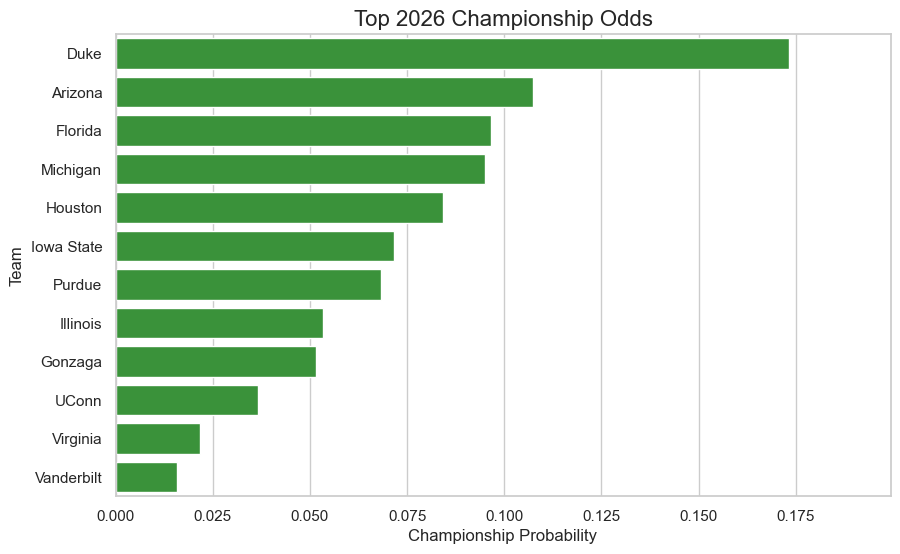

C:\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.

C:\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Python310\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Python310\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_group

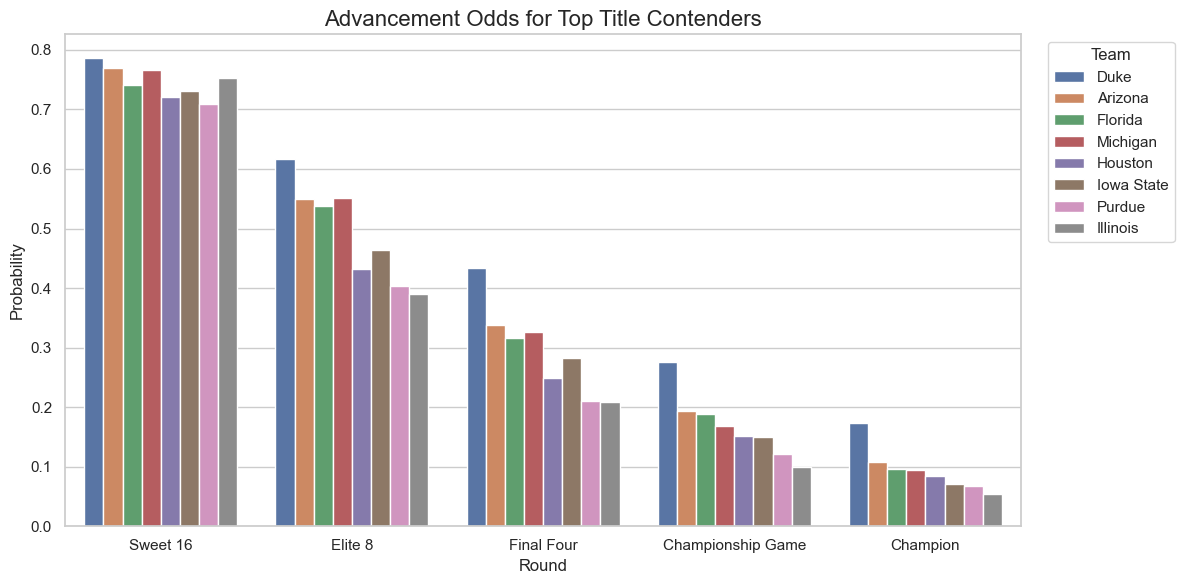

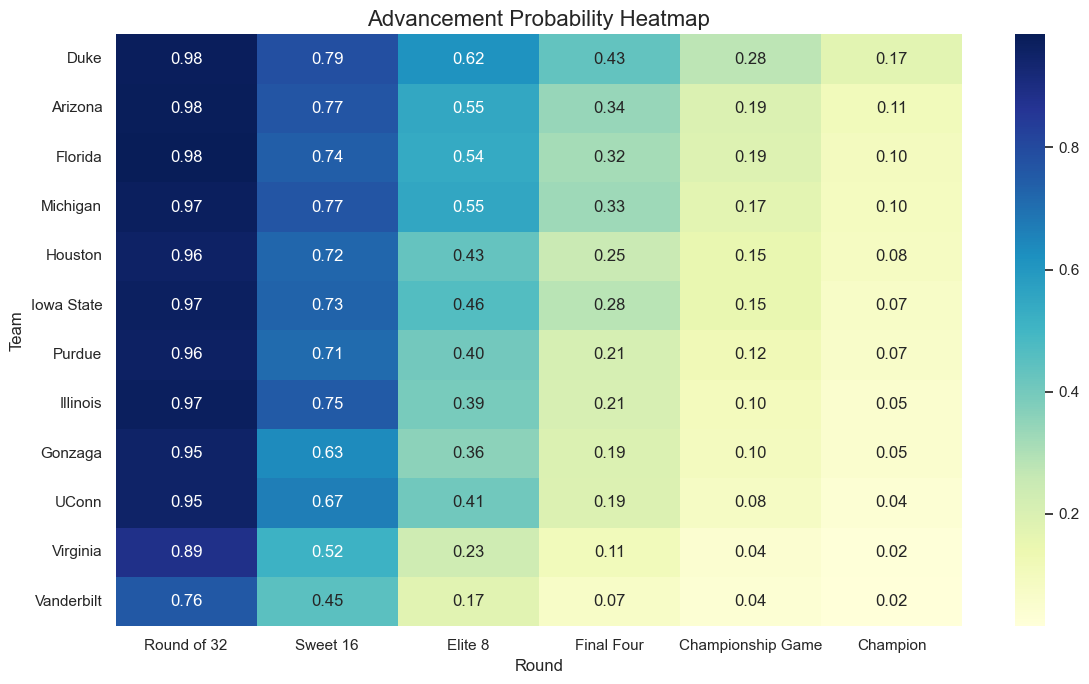

In [23]:
top_title_odds = monte_carlo_df[["team", "Final Four", "Championship Game", "Champion"]].head(15).copy()
top_title_odds["Final Four"] = top_title_odds["Final Four"].map(lambda x: f"{x:.1%}")
top_title_odds["Championship Game"] = top_title_odds["Championship Game"].map(lambda x: f"{x:.1%}")
top_title_odds["Champion"] = top_title_odds["Champion"].map(lambda x: f"{x:.1%}")
print("Deterministic champion:", title_game["winner"])
print("Title game:", finalist_1["team"], "vs", finalist_2["team"])
print()
print("Holdout comparison:")
display(holdout_df)
print()
print("Rolling backtest summary:")
display(backtest_summary_df)
print()
print("Top title odds:")
display(top_title_odds)

# Visualize the championship probabilities so the ranking is easy to read.
top_title_plot = monte_carlo_df.head(12).copy()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_title_plot, y="team", x="Champion", color="#2ca02c")
plt.title("Top 2026 Championship Odds")
plt.xlabel("Championship Probability")
plt.ylabel("Team")
plt.xlim(0, top_title_plot["Champion"].max() * 1.15)
plt.show()

# Show how likely the best teams are to reach each major round.
round_prob_plot = monte_carlo_df.head(8).melt(
    id_vars="team",
    value_vars=["Sweet 16", "Elite 8", "Final Four", "Championship Game", "Champion"],
    var_name="round",
    value_name="probability",
)
plt.figure(figsize=(12, 6))
sns.barplot(data=round_prob_plot, x="round", y="probability", hue="team")
plt.title("Advancement Odds for Top Title Contenders")
plt.xlabel("Round")
plt.ylabel("Probability")
plt.legend(title="Team", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Heatmaps are easier to scan quickly in a workshop than a long table of percentages.
advancement_heatmap_df = (
    monte_carlo_df.head(12)
    .set_index("team")[["Round of 32", "Sweet 16", "Elite 8", "Final Four", "Championship Game", "Champion"]]
)
plt.figure(figsize=(12, 7))
sns.heatmap(advancement_heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Advancement Probability Heatmap")
plt.xlabel("Round")
plt.ylabel("Team")
plt.tight_layout()
plt.show()


## Teaching Wrap-Up

This notebook now includes more beginner build-up, richer visuals, stronger baseline comparisons, clearer backtesting, recent-form and margin-based features, KenPom integration, and Monte Carlo tournament simulation.
